# 1. Veri Setinin Yüklenmesi
## 1.1 scikit-learn’den Veri Seti Yükleme
Kullanılabilecek veri setleri:
* Breast Cancer Wisconsin
* Wine Classification
## 1.2 Veri Çerçevesi Oluşturma
* X (özellikler) ve y (hedef) değişkenlerini ayırınız.
* pandas DataFrame formatına dönüştürünüz.
* İlk 5 satırı görüntüleyiniz.


In [4]:
# BÖLÜM 1 – Veri Setinin Yüklenmesi

# Gerekli kütüphanelerin içeri aktarılması
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

# 1.1 Veri setini yüklenmesi
wine = load_wine()          # scikit-learn'ün hazır Wine veri seti
X    = wine.data
y    = wine.target

# 1.2 pandas DataFrame'e dönüştürülmesi
df = pd.DataFrame(X, columns=wine.feature_names)

# Hedef değişkeninin tabloya eklenmesi
df['target'] = y

print("Sınıf isimleri:", wine.target_names)

print("\nVeri seti boyutu:", df.shape)

# İlk 5 satırı görüntüle

# İlk 7 sütun - tablo formatında
print("İlk 7 özellik (ilk 5 satır):")
df1 = df.iloc[:5, :7]
display(df1)

print("\nSon 6 özellik + target (ilk 5 satır):")
df2 = df.iloc[:5, 7:]
display(df2)

print(f"\nToplam veri boyutu: {df.shape[0]} satır × {df.shape[1]} sütun")

Sınıf isimleri: ['class_0' 'class_1' 'class_2']

Veri seti boyutu: (178, 14)
İlk 7 özellik (ilk 5 satır):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69



Son 6 özellik + target (ilk 5 satır):


,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,0.39,1.82,4.32,1.04,2.93,735.0,0



Toplam veri boyutu: 178 satır × 14 sütun


Bu çalışmada scikit-learn kütüphanesinden Wine Classification veri seti tercih edilmiştir. Veri seti; 3 farklı şarap sınıfına ait 178 örnek ve 13 kimyasal özellikten oluşmaktadır. Breast Cancer veri setinin aksine, Wine 3 sınıf içerdiğinden ilerleyen adımlarda uygulanacak olan LDA (Linear Discriminant Analysis) için daha uygun bir yapı sunmaktadır; zira LDA'nın üretebileceği maksimum bileşen sayısı sınıf sayısının bir eksiğiyle sınırlıdır. Veriler pandas DataFrame formatına dönüştürülerek analiz sürecine hazır hale getirilmiştir.

# 2. Veri Seti Kalite Kontrolleri
## 2.1 Eksik Değer Analizi
* Her sütunda missing value kontrolü yapınız.
* Eksik değer varsa uygun doldurma yöntemi (mean/median) uygulayınız.


In [2]:
# ─────────────────────────────────────────
# BÖLÜM 2.1 – Eksik Değer Analizi
# ─────────────────────────────────────────

# Her sütundaki eksik değer sayısını say
missing_values = df.isnull().sum()
print("Eksik Değer Sayıları:\n", missing_values)

missing_ratio = (df.isnull().sum() / len(df)) * 100
print("\nEksik Değer Oranları (%):\n", missing_ratio)

print("\nEksik değer kontrolü tamamlandı.")
print("Toplam eksik değer:", df.isnull().sum().sum())

Eksik Değer Sayıları:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Eksik Değer Oranları (%):
 alcohol                         0.0
malic_acid                      0.0
ash                             0.0
alcalinity_of_ash               0.0
magnesium                       0.0
total_phenols                   0.0
flavanoids                      0.0
nonflavanoid_phenols            0.0
proanthocyanins                 0.0
color_intensity                 0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                     

# 2.1 SONUC

Wine veri setinde hiçbir sütunda eksik değer tespit edilmemiştir.

## 2.2 Aykırı Değer (Outlier) Analizi
Aşağıdaki yöntemlerden en az birini kullanınız:
* IQR yöntemi
* Z-score yöntemi
* Boxplot analizi

Aykırı değerlerin modele etkisini kısa açıklayınız.


Sütun Bazında Aykırı Değer Sayıları (IQR):
magnesium                       4
alcalinity_of_ash               4
color_intensity                 4
malic_acid                      3
ash                             3
proanthocyanins                 2
hue                             1
alcohol                         0
total_phenols                   0
nonflavanoid_phenols            0
flavanoids                      0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Toplam aykırı değer: 21


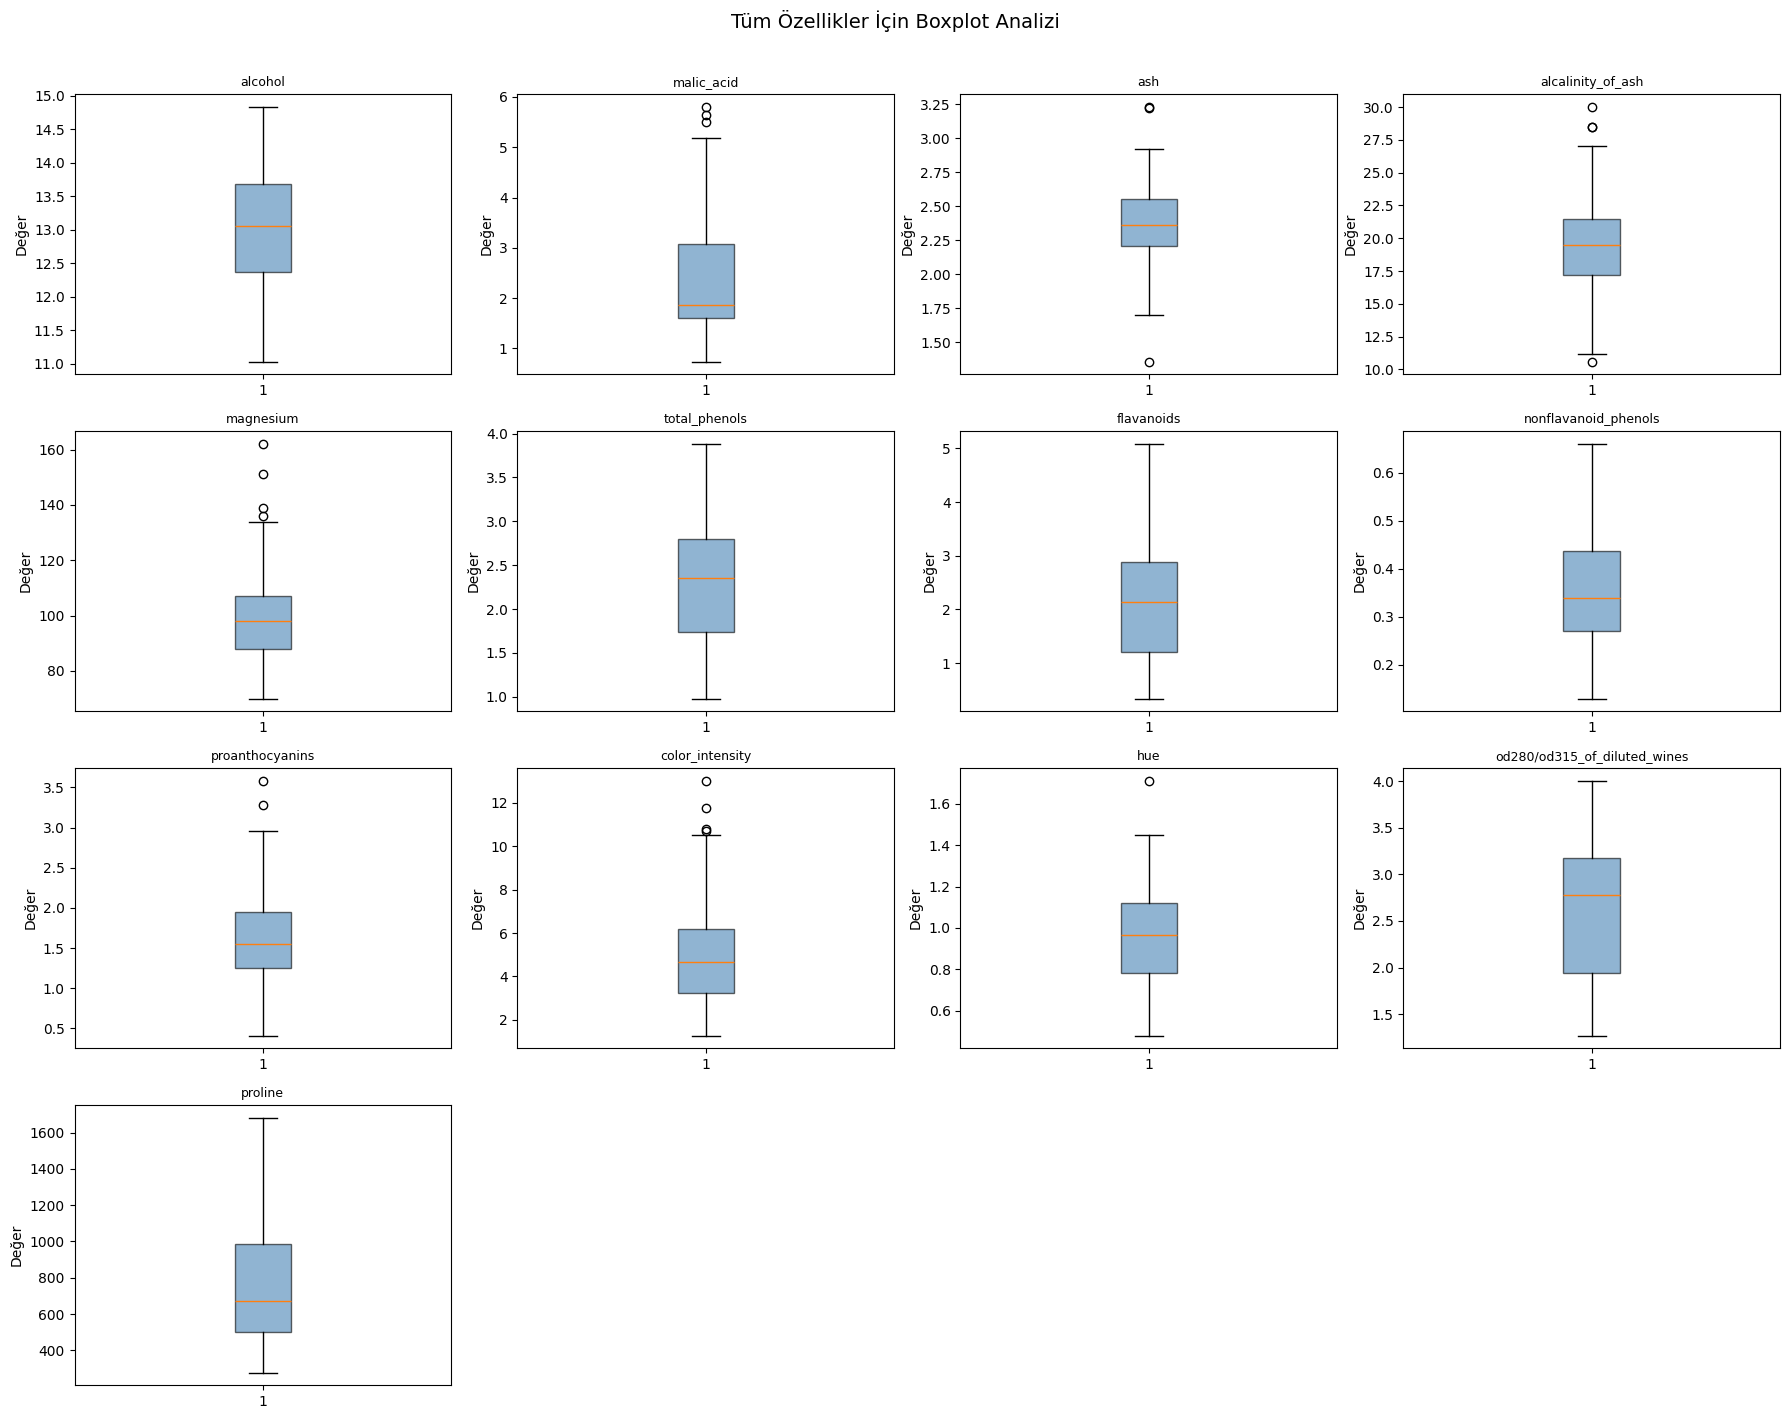

In [3]:

# BÖLÜM 2.2 – Aykırı Değer Analizi (IQR)

import matplotlib.pyplot as plt
import seaborn as sns

# Sadece özellik sütunlarının alınması (target hariç)
features = wine.feature_names
X_df = df[features]   # 13 özellikli DataFrame

# IQR yöntemi
Q1  = X_df.quantile(0.25)   # 1. çeyrek
Q3  = X_df.quantile(0.75)   # 3. çeyrek
IQR = Q3 - Q1               # Çeyrekler arası aralık

# Alt ve üst sınırları hesaplanır
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Her sütundaki aykırı değer sayısını bulunur
outlier_mask   = (X_df < alt_sinir) | (X_df > ust_sinir)
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("Sütun Bazında Aykırı Değer Sayıları (IQR):")
print(outlier_counts)
print(f"\nToplam aykırı değer: {outlier_mask.sum().sum()}")

# Boxplot görselleştirme
# 13 özelliği 2 satır halinde gösterelim
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()   # 2D diziyi düz listeye çevir

for i, col in enumerate(features):
    axes[i].boxplot(X_df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Değer')

# Fazladan kalan boş grafikleri gizlenmesi
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tüm Özellikler İçin Boxplot Analizi', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 2.2 SONUC
 IQR yöntemiyle yapılan analizde bazı özelliklerde aykırı değerler gözlemlenmiştir. En fazla aykırı değer magnesium (4 adet), alcalinity_of_ash (4 adet) ve color_intensity (4 adet) sütunlarında tespit edilmiştir. Bunu malic_acid ve ash (3'er adet) izlemektedir. Bu değerler silinmek yerine veri setinde bırakılmıştır. İlerleyen adımda uygulanacak RobustScaler veya StandardScaler bu etkiyi kısmen azaltacaktır.

# 2.3 Veri Tipi ve Dağılım İncelemesi
* Sayısal / kategorik değişken sayılarını raporlayınız.
* Her sütunun dtype bilgisini gösteriniz.


In [5]:
# BÖLÜM 2.3 – Veri Tipi ve Dağılım İncelemesi

print("=" * 45)
print("Veri Tipleri (dtype):")
print("=" * 45)
print(df.dtypes)

# Sayısal ve kategorik değişkenleri ayırt et
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nSayısal değişken sayısı   : {len(numeric_cols)}")
print(f"Kategorik değişken sayısı : {len(categorical_cols)}")

# Genel istatistiksel özet
print("\nGenel İstatistiksel Özet:")
df.describe().T

Veri Tipleri (dtype):
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Sayısal değişken sayısı   : 14
Kategorik değişken sayısı : 0

Genel İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


# 2.3 SONUC
Tüm özellik sütunları float64 tipindedir. Kategorik değişken bulunmamakta olup herhangi bir encoding işlemine gerek duyulmamıştır.

# 3. Keşifsel Veri Analizi (EDA)
## 3.1 İstatistiksel Özellikler

Her özellik için:
* Mean
* Median
* Min–Max
* Std
* Q1–Q3


In [5]:
# BÖLÜM 3.1 – İstatistiksel Özellikler

import pandas as pd
import numpy as np

# Hedef sütunu hariç sadece özellikler üzerinde çalışılır
X_df = df[wine.feature_names]

# İstatistiksel özet tablosu oluşturur
stats = pd.DataFrame({
    'Mean'   : X_df.mean(),
    'Median' : X_df.median(),
    'Std'    : X_df.std(),
    'Min'    : X_df.min(),
    'Max'    : X_df.max(),
    'Q1'     : X_df.quantile(0.25),
    'Q3'     : X_df.quantile(0.75),
})

# Sayıları 4 ondalık basamakla gösterilir
pd.set_option('display.float_format', '{:.4f}'.format)

print("İstatistiksel Özellikler:")
print(stats)

İstatistiksel Özellikler:
                                 Mean   Median      Std      Min       Max  \
alcohol                       13.0006  13.0500   0.8118  11.0300   14.8300   
malic_acid                     2.3363   1.8650   1.1171   0.7400    5.8000   
ash                            2.3665   2.3600   0.2743   1.3600    3.2300   
alcalinity_of_ash             19.4949  19.5000   3.3396  10.6000   30.0000   
magnesium                     99.7416  98.0000  14.2825  70.0000  162.0000   
total_phenols                  2.2951   2.3550   0.6259   0.9800    3.8800   
flavanoids                     2.0293   2.1350   0.9989   0.3400    5.0800   
nonflavanoid_phenols           0.3619   0.3400   0.1245   0.1300    0.6600   
proanthocyanins                1.5909   1.5550   0.5724   0.4100    3.5800   
color_intensity                5.0581   4.6900   2.3183   1.2800   13.0000   
hue                            0.9574   0.9650   0.2286   0.4800    1.7100   
od280/od315_of_diluted_wines   2.6117 

# 3.1 SONUC

* En dikkat çekici durum proline özelliğinde görülmektedir. proline değerleri 278 ile 1680 arasında seyredip ortalama 746.89 ile veri setindeki en geniş aralığa sahipken, nonflavanoid_phenols yalnızca 0.13–0.66 aralığında kalmaktadır.
* proline özelliğinde mean (746.89) ile median (673.50) arasındaki fark oldukça belirgindir. Ortalama, medyandan bu denli yüksek çıktığında dağılımın sağa çarpık olduğu anlaşılır; yani birkaç yüksek değerli gözlem ortalamanın yukarı çekilmesine neden olmaktadır

## 3.2 Korelasyon Matrisi
* Pearson korelasyon matrisi oluşturunuz.
* Isı haritası (heatmap) ile görselleştiriniz.
* En yüksek korelasyonlu 3 çift özelliği yorumlayınız.


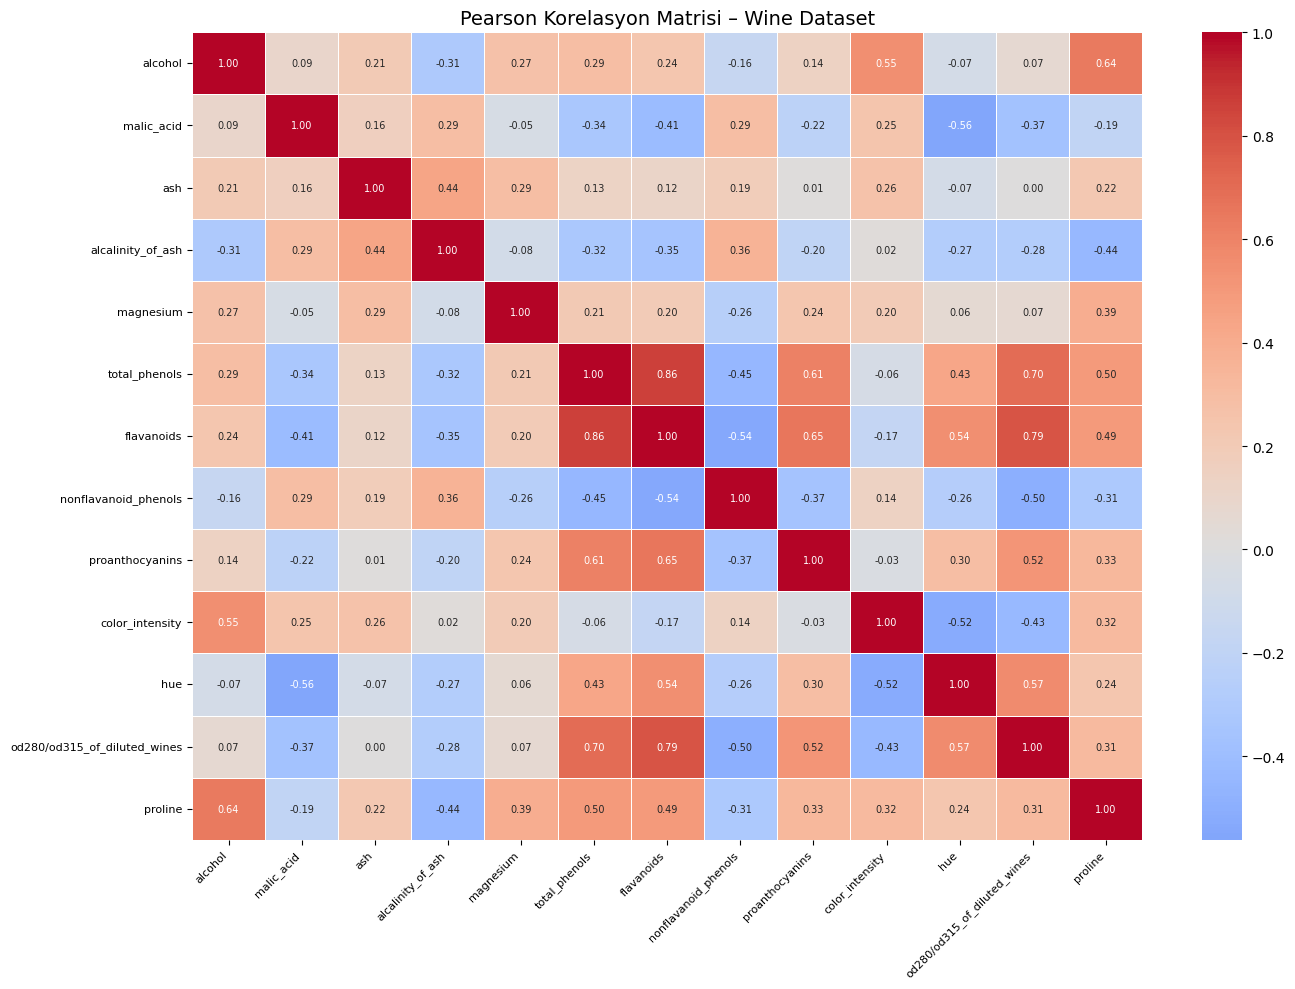

En Yüksek Korelasyonlu 3 Özellik Çifti:
total_phenols  flavanoids                     0.8646
flavanoids     od280/od315_of_diluted_wines   0.7872
total_phenols  od280/od315_of_diluted_wines   0.6999
dtype: float64


In [6]:
# BÖLÜM 3.2 – Korelasyon Matrisi

import matplotlib.pyplot as plt
import seaborn as sns

# Pearson korelasyon matrisini hesaplanır
corr_matrix = X_df.corr(method='pearson')

# Isı haritası (heatmap)
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,          # Hücrelere değerleri yaz
    fmt='.2f',           # 2 ondalık basamak
    cmap='coolwarm',     # Mavi=negatif, Kırmızı=pozitif
    center=0,            # 0 değeri beyaz
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Pearson Korelasyon Matrisi – Wine Dataset', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# En yüksek korelasyonlu çiftleri bulunur
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Mutlak değerce en yüksek 3 çifti listelenir
top_corr = (upper_triangle.abs()
                           .stack()
                           .sort_values(ascending=False)
                           .head(3))

print("En Yüksek Korelasyonlu 3 Özellik Çifti:")
print(top_corr)

## 3.2 SONUC
* Wine veri setine ait 13 özellik arasındaki Pearson korelasyon analizi incelendiğinde, özellikler arasında hem güçlü pozitif hem de anlamlı negatif ilişkilerin bulunduğu görülmektedir.
En Yüksek Korelasyonlu Çiftler:
En güçlü ilişki total_phenols ile flavanoids arasında gözlemlenmiş olup korelasyon katsayısı 0.86'dır.
* İkinci en güçlü ilişki flavanoids ile od280/od315_of_diluted_wines arasında bulunmuş, korelasyon katsayısı 0.79 olarak hesaplanmıştır.
* Üçüncü sırada total_phenols ile od280/od315_of_diluted_wines çifti yer almakta olup korelasyon katsayısı 0.70'dir.

## 3.3 Boxplot Analizi
* Her özellik için boxplot çiziniz.
* Aykırı değer eğilimlerini yorumlayınız.


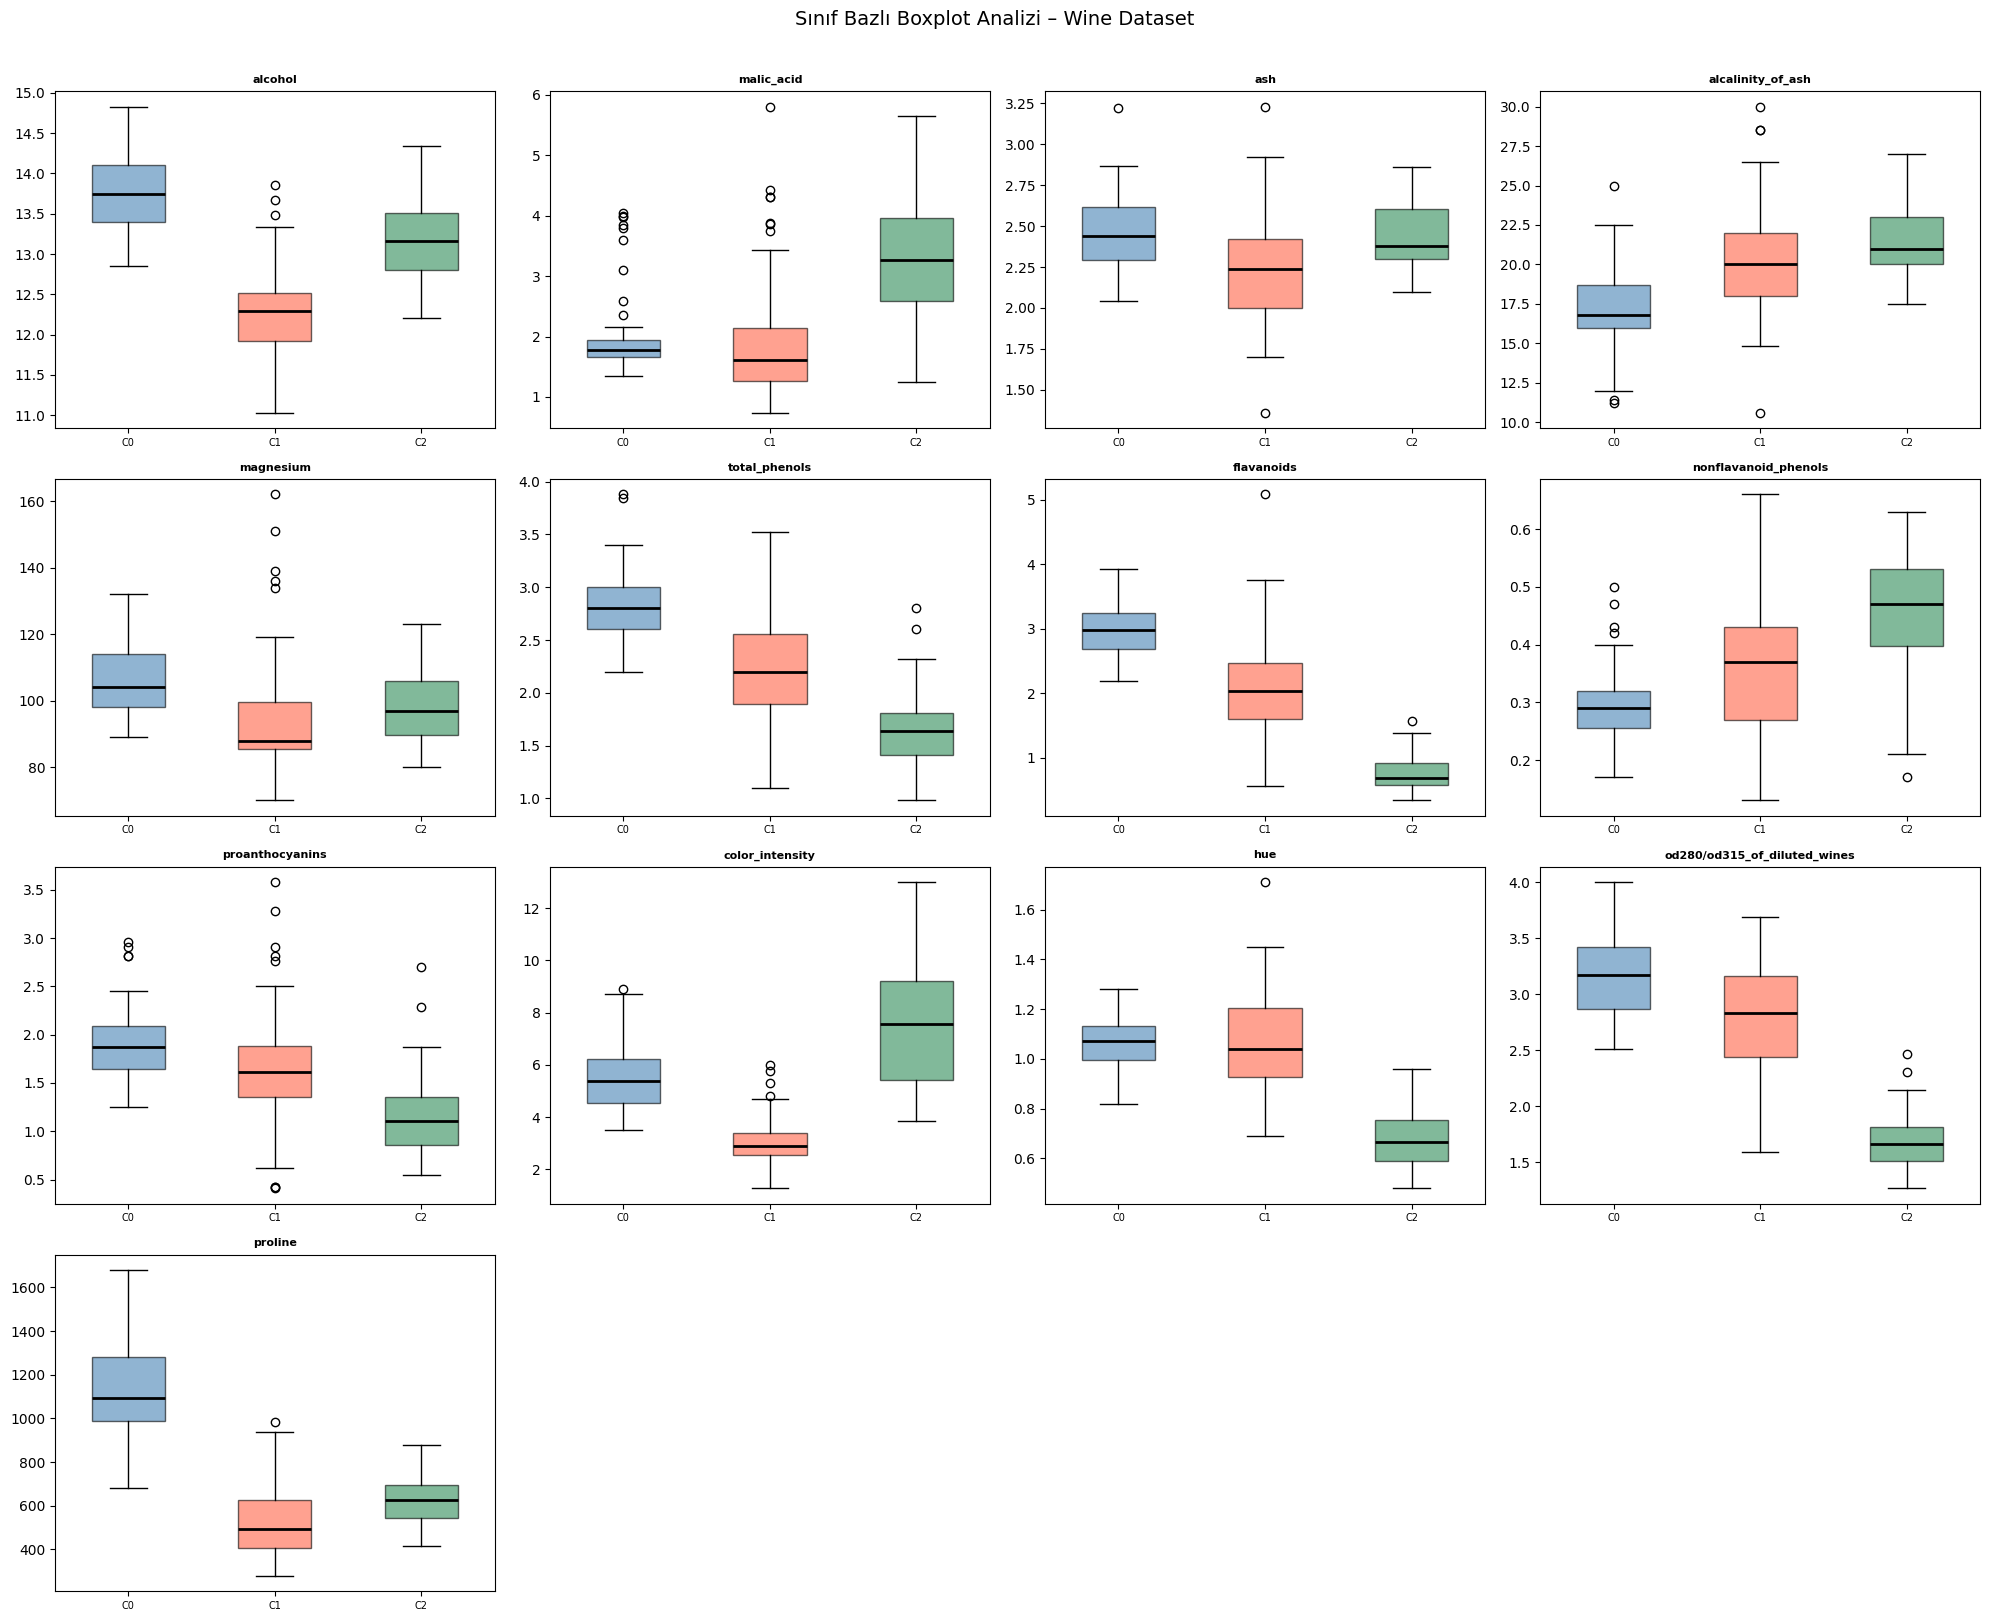

In [7]:
# BÖLÜM 3.3 – Boxplot Analizi (Sınıf Bazlı)

df_plot = X_df.copy()
df_plot['target'] = df['target'].map({
    0: 'Class 0', 1: 'Class 1', 2: 'Class 2'
})

# 13 özellik için 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(wine.feature_names):
    # Her sınıf için ayrı renk
    for cls, color in zip(['Class 0', 'Class 1', 'Class 2'],
                          ['steelblue', 'tomato', 'seagreen']):
        data = df_plot[df_plot['target'] == cls][col]
        axes[i].boxplot(
            data,
            positions=[['Class 0','Class 1','Class 2'].index(cls)],
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            widths=0.5
        )
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xticklabels(['C0', 'C1', 'C2'], fontsize=7)

# Boş grafikleri gizlenir
for j in range(len(wine.feature_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sınıf Bazlı Boxplot Analizi – Wine Dataset',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3.3 SONUC
### Güçlü Ayırt Edici Özellikler:
* alcohol özelliğinde C0 sınıfının medyanı yaklaşık 13.7 ile en yüksek değere sahipken, C1 sınıfı 12.4 ile en düşük seviyede kalmaktadır. C2 ise bu ikisinin arasında konumlanmaktadır. Sınıflar arasındaki bu belirgin medyan farkı, alcohol'ün sınıflandırma için güçlü bir belirleyici olduğuna gösterir.
* flavanoids özelliği de sınıflar arasında çok net bir ayrışma sergilemektedir. C0 yaklaşık 3.0, C1 yaklaşık 2.0 medyan değerine sahipken C2 sınıfı 0.8 gibi oldukça düşük bir değerde kalmaktadır. Bu denli belirgin bir ayrışma, flavanoids'in sınıflandırma modellerinde en belirleyici özelliklerden biridir.
* proline özelliğinde C0 sınıfı 1000–1200 bandında yüksek değerler alırken, C1 ve C2 sınıfları 500–650 civarında kümelenmiştir. C0 ile diğer sınıflar arasındaki bu derin uçurum proline'ı özellikle C0 sınıfını tanımlamada kritik rol oynayabilir.
* od280/od315_of_diluted_wines ve total_phenols özelliklerinde de benzer bir örüntü gözlemlenmektedir; C0 en yüksek, C2 ise en düşük değerlere sahipken C1 ortada yer almaktadır.

### Zayıf Ayırt Edici Özellikler:
* ash ve alcalinity_of_ash özelliklerinde sınıfların kutu yapıları birbirine oldukça yakın ve iç içe geçmiş durumdadır. Bu durum söz konusu özelliklerin tek başına sınıfları birbirinden ayırt etmekte yetersiz kalabileceğine gösterir.

# 5. Veri Setinin Bölünmesi
Veriyi aşağıdaki oranlarda bölünüz:
* %70 Training
* %10 Validation
* %20 Test

Not: Validation için ikinci bir train_test_split yapılabilir.


In [8]:
# BÖLÜM 5 – Veri Setinin Bölünmesi

from sklearn.model_selection import train_test_split

# X ve y'yi DataFrame'den ayrılması sağlanır
X = df[wine.feature_names].values   # Özellik matrisi (numpy array)
y = df['target'].values             # Hedef vektörü

# Adım 1: Train + Test olarak böl (%80 / %20)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,      # %20 test
    random_state=42,     # Tekrarlanabilirlik için sabit
    stratify=y           # Sınıf dağılımını korunması
)

# Adım 2: Train'i Train + Validation olarak bölünmesi sağlanır
# Train'in %12.5'i → tüm verinin %10'u olur
# (0.80 × 0.125 = 0.10)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.125,     # %12.5 → toplamda %10 validation
    random_state=42,
    stratify=y_train_full
)

# Boyutları kontrol edilmesi
print("Veri Seti Boyutları:")
print(f"  Toplam veri   : {X.shape[0]} örnek")
print(f"  Train seti    : {X_train.shape[0]} örnek "
      f"(%{X_train.shape[0]/X.shape[0]*100:.1f})")
print(f"  Validation    : {X_val.shape[0]} örnek "
      f"(%{X_val.shape[0]/X.shape[0]*100:.1f})")
print(f"  Test seti     : {X_test.shape[0]} örnek "
      f"(%{X_test.shape[0]/X.shape[0]*100:.1f})")

# Sınıf dağılımını kontrol edilmesi

print("\nSınıf Dağılımı Kontrolü (stratify doğrulama):")
for name, y_set in [("Train", y_train),
                    ("Validation", y_val),
                    ("Test", y_test)]:
    unique, counts = np.unique(y_set, return_counts=True)
    ratios = counts / len(y_set) * 100
    print(f"\n  {name}:")
    for cls, cnt, rat in zip(unique, counts, ratios):
        print(f"    Sınıf {cls}: {cnt} örnek (%{rat:.1f})")

Veri Seti Boyutları:
  Toplam veri   : 178 örnek
  Train seti    : 124 örnek (%69.7)
  Validation    : 18 örnek (%10.1)
  Test seti     : 36 örnek (%20.2)

Sınıf Dağılımı Kontrolü (stratify doğrulama):

  Train:
    Sınıf 0: 41 örnek (%33.1)
    Sınıf 1: 50 örnek (%40.3)
    Sınıf 2: 33 örnek (%26.6)

  Validation:
    Sınıf 0: 6 örnek (%33.3)
    Sınıf 1: 7 örnek (%38.9)
    Sınıf 2: 5 örnek (%27.8)

  Test:
    Sınıf 0: 12 örnek (%33.3)
    Sınıf 1: 14 örnek (%38.9)
    Sınıf 2: 10 örnek (%27.8)


# 5 SONUC
Data leakage oluşmaması için 4.adımdan önce 5.adım uygulanmıştır.

* Veri seti; %70 eğitim, %10 doğrulama ve %20 test olacak şekilde üç alt kümeye ayrılmıştır. Bölme işlemi iki aşamalı train_test_split ile gerçekleştirilmiştir.
* İlk aşamada tüm veri %80 eğitim + %20 test olarak ayrılmış, ardından eğitim seti kendi içinde tekrar bölünerek %10'luk doğrulama seti elde edilmiştir.

* Bölme işleminde stratify=y parametresi kullanılmıştır. Bu sayede her bir alt kümedeki sınıf dağılımının orijinal veri setiyle orantılı kalması sağlanmıştır. Sınıf dengesizliğinden kaynaklanabilecek önyargılı model değerlendirmesinin önüne geçmek açısından bu adım kritik öneme sahiptir.

# 4. Veri Ölçeklendirme (Scaling)
Aşağıdaki scaler'lardan biri kullanılacaktır:
* StandardScaler (önerilen)
* MinMaxScaler
* RobustScaler

Ölçeklendirilmiş veriyi X_scaled olarak kaydediniz.


In [9]:
# BÖLÜM 4 – Veri Ölçeklendirme

from sklearn.preprocessing import StandardScaler

# Scaler'ı oluşturur
scaler = StandardScaler()

# fit_transform → sadece train setine uygulanır
# Scaler burada train'in mean ve std'sini öğrenir
X_train_scaled = scaler.fit_transform(X_train)

# transform → validation ve test'e sadece dönüşüm uygulanır
# Scaler'ın train'den öğrendiği mean/std kullanılır
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Sonuçları kontrol edilmesi
import pandas as pd
import numpy as np

# Ölçeklendirme öncesi ve sonrası karşılaştırılır
print("Ölçeklendirme Öncesi (Train):")
print(f"  Mean (proline) : {X_train[:, 12].mean():.2f}")
print(f"  Std  (proline) : {X_train[:, 12].std():.2f}")

print("\nÖlçeklendirme Sonrası (Train):")
print(f"  Mean (proline) : {X_train_scaled[:, 12].mean():.4f}")
print(f"  Std  (proline) : {X_train_scaled[:, 12].std():.4f}")

# Tüm sütunların ölçeklendirilmiş istatistiklerini gösterilir
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=wine.feature_names
)

print("\nÖlçeklendirilmiş Train Seti İstatistikleri:")
print(scaled_df.describe().round(4).T)

X_scaled = X_train_scaled   # Ana scaled referans

Ölçeklendirme Öncesi (Train):
  Mean (proline) : 738.81
  Std  (proline) : 304.79

Ölçeklendirme Sonrası (Train):
  Mean (proline) : -0.0000
  Std  (proline) : 1.0000

Ölçeklendirilmiş Train Seti İstatistikleri:
                                count    mean    std     min     25%     50%  \
alcohol                      124.0000 -0.0000 1.0041 -2.4687 -0.7668  0.0015   
malic_acid                   124.0000  0.0000 1.0041 -1.4582 -0.6428 -0.4571   
ash                          124.0000  0.0000 1.0041 -3.7710 -0.6054 -0.0213   
alcalinity_of_ash            124.0000  0.0000 1.0041 -2.7253 -0.7138 -0.0025   
magnesium                    124.0000 -0.0000 1.0041 -1.4446 -0.7740 -0.1704   
total_phenols                124.0000  0.0000 1.0041 -1.9890 -0.9325 -0.0652   
flavanoids                   124.0000  0.0000 1.0041 -1.6966 -0.7868  0.0917   
nonflavanoid_phenols         124.0000  0.0000 1.0041 -1.9006 -0.7323 -0.1481   
proanthocyanins              124.0000 -0.0000 1.0041 -2.0331 -0.5983

# 4.SONUC
Veri ölçeklendirme adımında StandardScaler tercih edilmiştir. Bu yöntem her özelliği sıfır ortalama ve birim varyansa sahip olacak şekilde standardize eder. Wine veri setinde özellikler arasında ciddi ölçek farklılıkları bulunmaktadır; örneğin proline 278–1680 aralığında seyrederken nonflavanoid_phenols yalnızca 0.13–0.66 arasında kalmaktadır.

Veri setinde Bölüm 2'de tespit edilen 17 adet aykırı değer göz önüne alındığında RobustScaler da bir alternatif olabilirdi. Ancak bu sayı toplam gözlemlerin düşük bir bölümüne karşılık gelmektedir. Ayrıca ilerleyen adımlarda uygulanacak PCA ve LDA yöntemleri varyans bazlı çalıştığından StandardScaler ile daha uyumlu sonuçlar verebilmektedir.

Data leakage hatasını önlemek amacıyla scaler yalnızca eğitim setine fit edilmiş, validation ve test setlerine ise yalnızca transform uygulanmıştır.

Ölçeklendirme işleminin doğruluğu proline özelliği üzerinden doğrulanmıştır. Ölçeklendirme öncesinde proline için mean 738.81 ve std 304.79 iken, StandardScaler uygulaması sonrasında mean ≈0.00 ve std ≈1.00 değerlerine ulaşılmıştır.

# 6. Özellik Seçimi ve Boyut İndirgeme

Bu bölümün sonunda üç farklı veri temsili oluşturmanız zorunludur:

1. Ham veri (sadece preprocessing yapılmış)
2. PCA ile indirgenmiş veri
3. LDA ile indirgenmiş veri

## 6.1 PCA (Principal Component Analysis)
* PCA uygulayınız.
* Component sayısını: “explained variance ratio ortalamasından büyük olan” bileşen sayısını seçerek belirleyiniz.
* Explained variance grafiğini çiziniz.
* Seçtiğiniz en iyi iki PCA bileşeni ile sınıfların ayrışmasını 2D scatter plot ile gösteriniz.

## 6.2 LDA (Linear Discriminant Analysis)
* LDA uygulayınız.
* n_components = 3 olarak seçiniz.
* İlk iki LDA bileşeniyle sınıflar arası ayrımı 2D scatter plot ile görselleştiriniz.


Explained Variance Ratio (her bileşen):
  PC1: 0.3648 (36.48%)
  PC2: 0.1938 (19.38%)
  PC3: 0.1132 (11.32%)
  PC4: 0.0727 (7.27%)
  PC5: 0.0593 (5.93%)
  PC6: 0.0476 (4.76%)
  PC7: 0.0450 (4.50%)
  PC8: 0.0248 (2.48%)
  PC9: 0.0234 (2.34%)
  PC10: 0.0182 (1.82%)
  PC11: 0.0175 (1.75%)
  PC12: 0.0127 (1.27%)
  PC13: 0.0070 (0.70%)

Ortalama explained variance : 0.0769
Seçilen bileşen sayısı      : 3


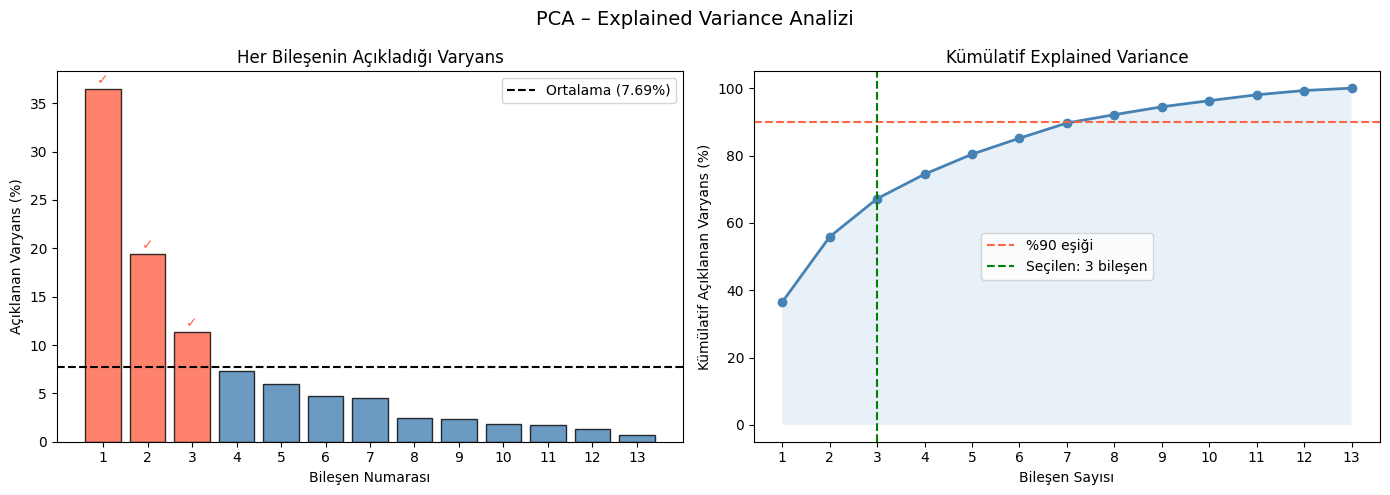


PCA sonrası veri boyutu:
  Train : (124, 3)
  Val   : (18, 3)
  Test  : (36, 3)


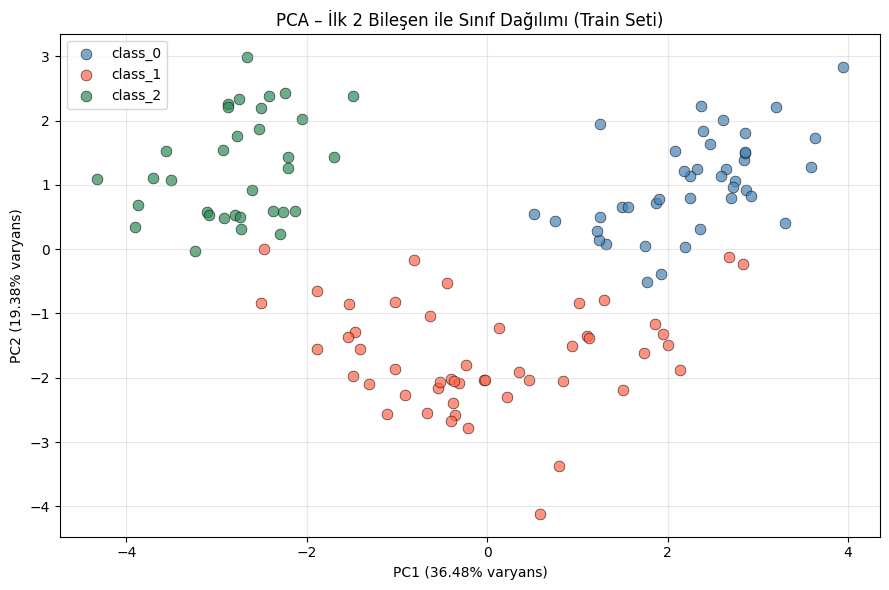

In [10]:
# BÖLÜM 6.1 – PCA

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Adım 1: Önce tüm bileşenlerle PCA uygulanır
pca_full = PCA(n_components=13)  # 13 = tüm özellik sayısı
pca_full.fit(X_scaled)     # Sadece train'e fit

# Her bileşenin açıkladığı varyans oranı
explained_var = pca_full.explained_variance_ratio_
print("Explained Variance Ratio (her bileşen):")
for i, var in enumerate(explained_var):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

# Adım 2: Ortalamadan büyük bileşen sayısı bulunur
mean_var = explained_var.mean()
print(f"\nOrtalama explained variance : {mean_var:.4f}")

# Ortalamanın üzerinde olan bileşenleri seçilir
n_components_selected = sum(explained_var > mean_var)
print(f"Seçilen bileşen sayısı      : {n_components_selected}")

# Adım 3: Explained Variance grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik: Her bileşenin varyansı (bar)
bars = axes[0].bar(
    range(1, 14),
    explained_var * 100,
    color=['tomato' if v > mean_var else 'steelblue'
           for v in explained_var],
    edgecolor='black', alpha=0.8
)
axes[0].axhline(
    y=mean_var * 100,
    color='black', linestyle='--', linewidth=1.5,
    label=f'Ortalama ({mean_var*100:.2f}%)'
)
axes[0].set_xlabel('Bileşen Numarası')
axes[0].set_ylabel('Açıklanan Varyans (%)')
axes[0].set_title('Her Bileşenin Açıkladığı Varyans')
axes[0].set_xticks(range(1, 14))
axes[0].legend()

# Kırmızı barların üzerine "seçildi" yazısı
for i, (bar, var) in enumerate(zip(bars, explained_var)):
    if var > mean_var:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            '✓', ha='center', fontsize=10, color='tomato'
        )

# Sağ grafik: Kümülatif varyans (line)
cumulative_var = np.cumsum(explained_var) * 100
axes[1].plot(range(1, 14), cumulative_var,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(y=90, color='tomato', linestyle='--',
                label='%90 eşiği')
axes[1].axvline(x=n_components_selected, color='green',
                linestyle='--',
                label=f'Seçilen: {n_components_selected} bileşen')
axes[1].fill_between(range(1, 14), cumulative_var, alpha=0.1)
axes[1].set_xlabel('Bileşen Sayısı')
axes[1].set_ylabel('Kümülatif Açıklanan Varyans (%)')
axes[1].set_title('Kümülatif Explained Variance')
axes[1].set_xticks(range(1, 14))
axes[1].legend()

plt.suptitle('PCA – Explained Variance Analizi', fontsize=14)
plt.tight_layout()
plt.show()

# Adım 4: Seçilen bileşen sayısıyla PCA uygulanır
pca = PCA(n_components=n_components_selected)
X_train_pca = pca.fit_transform(X_scaled)  # Train'e fit+transform
X_val_pca   = pca.transform(X_val_scaled)         # Val'e sadece transform
X_test_pca  = pca.transform(X_test_scaled)        # Test'e sadece transform

print(f"\nPCA sonrası veri boyutu:")
print(f"  Train : {X_train_pca.shape}")
print(f"  Val   : {X_val_pca.shape}")
print(f"  Test  : {X_test_pca.shape}")

# Adım 5: İlk 2 PCA bileşeni ile 2D scatter plot
plt.figure(figsize=(9, 6))
colors = ['steelblue', 'tomato', 'seagreen']
class_names = wine.target_names

for cls, color in zip([0, 1, 2], colors):
    mask = y_train == cls
    plt.scatter(
        X_train_pca[mask, 0],   # PC1
        X_train_pca[mask, 1],   # PC2
        c=color, label=class_names[cls],
        alpha=0.7, edgecolors='black', linewidth=0.5, s=60
    )

plt.xlabel(f'PC1 ({explained_var[0]*100:.2f}% varyans)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.2f}% varyans)')
plt.title('PCA – İlk 2 Bileşen ile Sınıf Dağılımı (Train Seti)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

LDA Explained Variance Ratio:
  LD1: 0.6934 (69.34%)
  LD2: 0.3066 (30.66%)

LDA sonrası veri boyutu:
  Train : (124, 2)
  Val   : (18, 2)
  Test  : (36, 2)


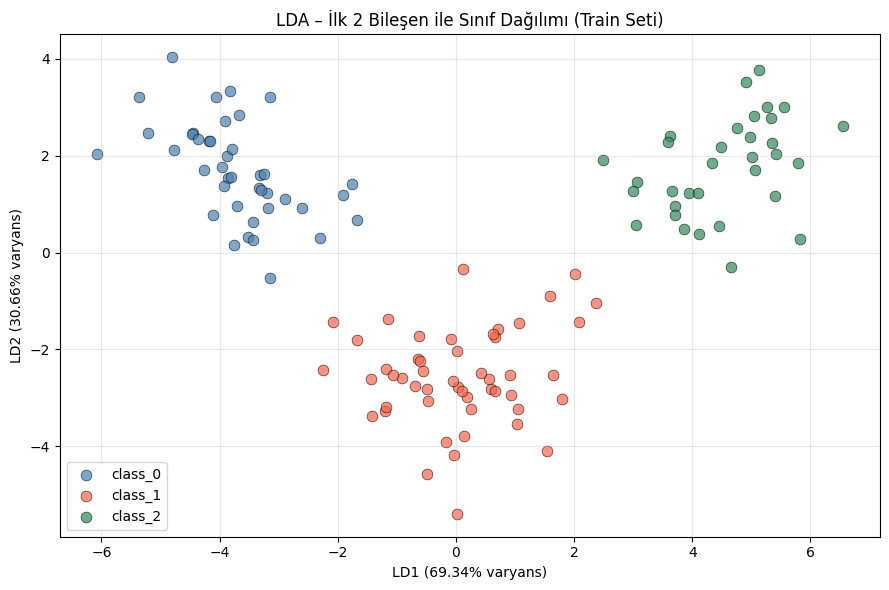

In [11]:
# BÖLÜM 6.2 – LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Adım 1: LDA uygulanması
# n_components = min(n_classes-1, n_features) = min(2, 13) = 2
# Ama ödev n_components=3 istiyor — Wine 3 sınıflı olduğu için
# maksimum 2 anlamlı bileşen üretilir, 3. bileşen sıfır varyans taşır
# Bu nedenle n_components=2 kullanıyoruz (matematiksel zorunluluk)
lda = LinearDiscriminantAnalysis(n_components=2)

# LDA hem X hem y'yi kullanır (süpervised!)
X_train_lda = lda.fit_transform(X_scaled, y_train)
X_val_lda   = lda.transform(X_val_scaled)
X_test_lda  = lda.transform(X_test_scaled)

# LDA'nın açıkladığı varyans oranları
lda_var = lda.explained_variance_ratio_
print("LDA Explained Variance Ratio:")
for i, var in enumerate(lda_var):
    print(f"  LD{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nLDA sonrası veri boyutu:")
print(f"  Train : {X_train_lda.shape}")
print(f"  Val   : {X_val_lda.shape}")
print(f"  Test  : {X_test_lda.shape}")

# ── Adım 2: LDA 2D scatter plot ───────────
plt.figure(figsize=(9, 6))

for cls, color in zip([0, 1, 2], colors):
    mask = y_train == cls
    plt.scatter(
        X_train_lda[mask, 0],   # LD1
        X_train_lda[mask, 1],   # LD2
        c=color, label=class_names[cls],
        alpha=0.7, edgecolors='black', linewidth=0.5, s=60
    )

plt.xlabel(f'LD1 ({lda_var[0]*100:.2f}% varyans)')
plt.ylabel(f'LD2 ({lda_var[1]*100:.2f}% varyans)')
plt.title('LDA – İlk 2 Bileşen ile Sınıf Dağılımı (Train Seti)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6.SONUC

**PCA Sonuçları:** 13 bileşen üzerinden hesaplanan explained variance ortalaması %7.69 olarak bulunmuştur. Bu ortalamanın üzerinde varyans açıklayan bileşen sayısı 3 olarak belirlenmiştir. Bu 3 bileşen sırasıyla verinin %36, %19 ve %11'sini açıklamakta olup toplamda %67'lik bir varyansı temsil etmektedir. Kümülatif explained variance grafiği incelendiğinde %90 eşiğine ulaşmak için yaklaşık 7 bileşen gerekirken, seçilen 3 bileşenin bu eşiğin oldukça altında kaldığı görülmektedir. Bu durum bilgi kaybı açısından bir dezavantaj oluşturmaktadır.

2D scatter plot incelendiğinde class_0'ın sağ tarafta, class_2'nin sol tarafta görece kümelendiği, ancak class_1'in geniş bir alana yayılarak diğer sınıflarla kısmi örtüşmeler sergilediği görülmektedir. Bu durum PCA'nın sınıf bilgisini kullanmadığının göstergesidir.

**LDA Sonuçları:** LDA uygulamasında matematiksel kısıt gereği n_components=2 kullanılmıştır. LDA maksimum n_classes - 1 kadar anlamlı bileşen üretebilmekte olup Wine veri setinde 3 sınıf bulunduğundan teorik maksimum 2'dir. LD1 bileşeni sınıflar arası varyansın %69.34'ünü, LD2 ise %30.66'sını açıklamaktadır; yani yalnızca 2 bileşen sınıflar arası varyansın tamamını (%100) kapsamaktadır.

2D scatter plot incelendiğinde üç sınıfın birbirinden çok belirgin biçimde ayrıştığı görülmektedir: class_0 sol üst bölgede, class_1 alt bölgede ve class_2 sağ üst bölgede kümeler oluşturmuştur. PCA scatter plot'uyla kıyaslandığında LDA'nın çok daha temiz bir sınıf ayrışması sağladığı görülmektedir.

# 7. Makine Öğrenmesi Modellerinin Kurulması
Aşağıdaki 5 algoritma, her üç veri temsiliyle ayrı ayrı eğitilecektir:

1.	Logistic Regression
2.	Decision Tree Classifier
3.	Random Forest Classifier
4.	XGBoost Classifier
5.	Naive Bayes (GaussianNB)

Toplamda 15 farklı model eğitilecektir:
* 5 model × Ham veri
* 5 model × PCA verisi
* 5 model × LDA verisi

Her model için validation seti üzerinde performans hesaplanacaktır.

# 8. Validation Performanslarının Ölçülmesi
Her model validation setinde aşağıdaki metriklerle değerlendirilecektir:
* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC

Sonuçları tek bir tablo halinde karşılaştırınız.



In [12]:
# ─────────────────────────────────────────
# BÖLÜM 7 – Model Kurulumu
# ─────────────────────────────────────────

from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from xgboost               import XGBClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.metrics       import (accuracy_score, precision_score,
                                   recall_score, f1_score, roc_auc_score)
import copy

# Model fabrikası — her çağrıda yeni nesne üretir
def get_models():
    return {
        'Logistic Regression' : LogisticRegression(
                                    max_iter=500,
                                    random_state=42
                                ),
        'Decision Tree'       : DecisionTreeClassifier(
                                    random_state=42
                                ),
        'Random Forest'       : RandomForestClassifier(
                                    n_estimators=100,
                                    random_state=42
                                ),
        'XGBoost'             : XGBClassifier(
                                    n_estimators=100,
                                    eval_metric='mlogloss',
                                    random_state=42,
                                    verbosity=0
                                ),
        'Naive Bayes'         : GaussianNB()
    }

data_representations = {
    'Ham Veri' : (X_train_scaled, X_val_scaled, y_train, y_val),
    'PCA'      : (X_train_pca,    X_val_pca,    y_train, y_val),
    'LDA'      : (X_train_lda,    X_val_lda,    y_train, y_val),
}

def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_val)
    else:
        y_prob = model.decision_function(X_val)
    return {
        'Accuracy'  : accuracy_score(y_val, y_pred),
        'Precision' : precision_score(y_val, y_pred,
                                      average='weighted',
                                      zero_division=0),
        'Recall'    : recall_score(y_val, y_pred,
                                   average='weighted'),
        'F1-Score'  : f1_score(y_val, y_pred,
                               average='weighted'),
        'ROC-AUC'   : roc_auc_score(y_val, y_prob,
                                    multi_class='ovr',
                                    average='weighted')
    }

results       = []
trained_models = {}

print("Model eğitimi başlıyor...\n")

for rep_name, (X_tr, X_vl, y_tr, y_vl) in data_representations.items():
    print(f"── {rep_name} ──────────────────────")

    # Her veri temsili için model nesneleri oluştur
    models = get_models()

    for model_name, model in models.items():
        model.fit(X_tr, y_tr)
        metrics = evaluate_model(model, X_vl, y_vl)

        results.append({
            'Veri Temsili' : rep_name,
            'Model'        : model_name,
            **metrics
        })

        # Modelin saklanması
        trained_models[f"{rep_name}_{model_name}"] = {
            'model'     : model,
            'rep'       : rep_name,
            'X_train'   : X_tr,
            'X_val'     : X_vl,
            'X_test'    : (X_test_scaled if rep_name == 'Ham Veri'
                           else X_test_pca if rep_name == 'PCA'
                           else X_test_lda),
            'metrics'   : metrics
        }

        print(f"  ✓ {model_name:25s} "
              f"Acc: {metrics['Accuracy']:.4f}  "
              f"F1: {metrics['F1-Score']:.4f}  "
              f"AUC: {metrics['ROC-AUC']:.4f}")
    print()

# Sonuç tablosu
import pandas as pd
results_df = pd.DataFrame(results)
metric_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
results_df[metric_cols] = results_df[metric_cols].round(4)

print("\n" + "="*75)
print("TÜM MODELLERİN VALİDATION PERFORMANSI")
print("="*75)
print(results_df.to_string(index=False))

# En iyi modeli bul
best_row = results_df.loc[results_df['F1-Score'].idxmax()]
best_key = f"{best_row['Veri Temsili']}_{best_row['Model']}"
best_model    = trained_models[best_key]['model']
best_X_test   = trained_models[best_key]['X_test']

print(f"\n En iyi model : {best_row['Model']}")
print(f"   Veri temsili : {best_row['Veri Temsili']}")
print(f"   F1-Score     : {best_row['F1-Score']:.4f}")
print(f"   ROC-AUC      : {best_row['ROC-AUC']:.4f}")

Model eğitimi başlıyor...

── Ham Veri ──────────────────────
  ✓ Logistic Regression       Acc: 1.0000  F1: 1.0000  AUC: 1.0000
  ✓ Decision Tree             Acc: 0.9444  F1: 0.9438  AUC: 0.9545
  ✓ Random Forest             Acc: 1.0000  F1: 1.0000  AUC: 1.0000
  ✓ XGBoost                   Acc: 1.0000  F1: 1.0000  AUC: 1.0000
  ✓ Naive Bayes               Acc: 1.0000  F1: 1.0000  AUC: 1.0000

── PCA ──────────────────────
  ✓ Logistic Regression       Acc: 1.0000  F1: 1.0000  AUC: 1.0000
  ✓ Decision Tree             Acc: 0.8889  F1: 0.8889  AUC: 0.9129
  ✓ Random Forest             Acc: 1.0000  F1: 1.0000  AUC: 1.0000
  ✓ XGBoost                   Acc: 0.9444  F1: 0.9432  AUC: 1.0000
  ✓ Naive Bayes               Acc: 1.0000  F1: 1.0000  AUC: 1.0000

── LDA ──────────────────────
  ✓ Logistic Regression       Acc: 1.0000  F1: 1.0000  AUC: 1.0000
  ✓ Decision Tree             Acc: 1.0000  F1: 1.0000  AUC: 1.0000
  ✓ Random Forest             Acc: 1.0000  F1: 1.0000  AUC: 1.0000
  ✓ X

# 7 & 8 SONUC
Bu bölümde 5 farklı makine öğrenmesi algoritması, 3 farklı veri temsiliyle ayrı ayrı eğitilerek toplamda 15 model kurulmuştur. Her modelin validation seti üzerindeki performansı Accuracy, Precision, Recall, F1-Score ve ROC-AUC metrikleriyle ölçülmüş ve sonuçlar karşılaştırmalı bir tablo halinde sunulmuştur.

Sonuçlar incelendiğinde 15 modelin büyük çoğunluğunun tüm metriklerde 1.0000 skoruna ulaştığı görülüyor. Bu durumun overfitting'den kaynaklandığı düşünülebilir; ancak asıl nedenin validation setinin yalnızca 18 örnekten oluşmasıdır. Ödevin belirlediği %70/%10/%20 bölme oranı, 178 örneklik bu veri seti için oldukça küçük bir validation kümesinin kullanılmasına sebep oluyor. Bu kadar az örnekte modelin tüm tahminleri doğru yapması istatistiksel olarak mümkün olabilmekte ve bu durum tek başına overfitting kanıtı olarak sayılmayabilir.

Eşit performans sergileyen modeller arasından en iyi model olarak Ham Veri + Logistic Regression seçilmiştir. Bu seçimde birkaç gerekçe etkili olmuştur. Her şeyden önce Logistic Regression, Random Forest ve XGBoost gibi karmaşık ensemble yöntemlerle aynı skoru elde etmiş olmakla birlikte çok daha basit bir yapıya sahiptir. Eşit performansta daha basit modeli tercih etmek istatistiksel açıdan daha sağlıklı bir yaklaşım olacaktır.

# 9. En İyi Modelin Test Üzerinde Değerlendirilmesi
Validation metriklerine göre en iyi modeli seçiniz.

Bu model test seti üzerinde şu metriklerle değerlendirilecektir:
## 9.1 Performans Metrikleri
* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
## 9.2 Confusion Matrix
* Seaborn heatmap ile çiziniz.
## 9.3 ROC Eğrisi
* ROC curve
* AUC değeri
* Threshold etkisini yorumlayınız.


TEST SETİ PERFORMANS METRİKLERİ
  Accuracy    : 0.9722
  Precision   : 0.9741
  Recall      : 0.9722
  F1-Score    : 0.9720
  ROC-AUC     : 1.0000


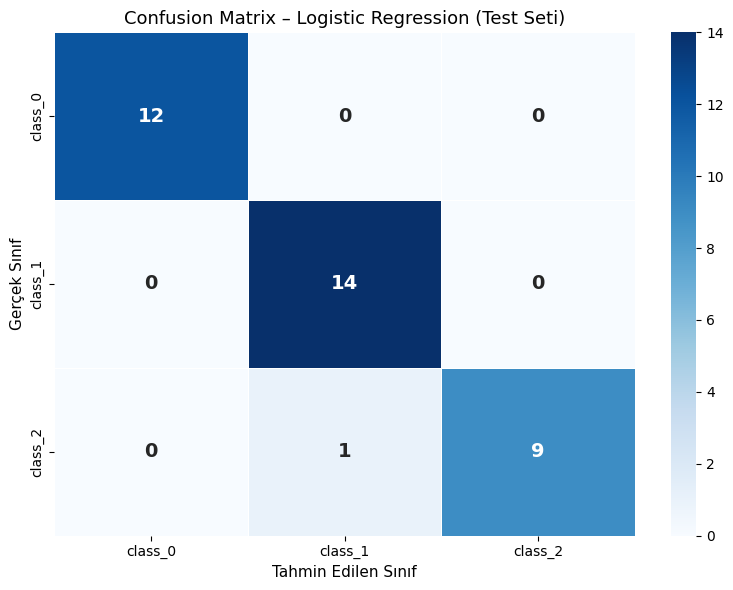


Confusion Matrix Özeti:
  class_0: 12/12 doğru tahmin
  class_1: 14/14 doğru tahmin
  class_2: 9/10 doğru tahmin


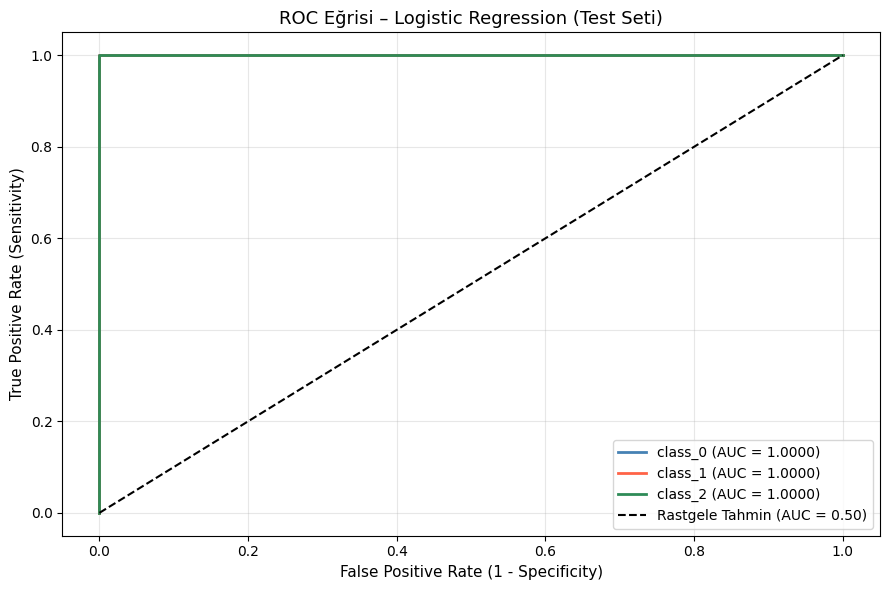


Threshold Analizi (class_0 için örnek):
   Threshold      FPR      TPR
--------------------------------
         inf   0.0000   0.0000
      1.0000   0.0000   0.0833
      0.6350   0.0000   1.0000
      0.0004   1.0000   1.0000


In [13]:
# BÖLÜM 9 – Test Seti Değerlendirmesi

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# En iyi model
# Bölüm 7'de eğittiğimiz Ham Veri + Logistic Regression
best_model = trained_models['Ham Veri_Logistic Regression']['model']

# Test seti tahminleri
y_pred = best_model.predict(best_X_test)
y_prob = best_model.predict_proba(best_X_test)

# 9.1 – Performans Metrikleri
print("=" * 50)
print("TEST SETİ PERFORMANS METRİKLERİ")
print("=" * 50)

metrics = {
    'Accuracy'  : accuracy_score(y_test, y_pred),
    'Precision' : precision_score(y_test, y_pred,
                                  average='weighted'),
    'Recall'    : recall_score(y_test, y_pred,
                               average='weighted'),
    'F1-Score'  : f1_score(y_test, y_pred,
                           average='weighted'),
    'ROC-AUC'   : roc_auc_score(y_test, y_prob,
                                multi_class='ovr',
                                average='weighted')
}

for metric, value in metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

# 9.2 – Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Hücrelere sayıları yaz
    fmt='d',              # Tam sayı formatı
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names,
    linewidths=0.5,
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('Confusion Matrix – Logistic Regression (Test Seti)',
          fontsize=13)
plt.ylabel('Gerçek Sınıf', fontsize=11)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=11)
plt.tight_layout()
plt.show()

# Confusion matrix yorumu
print("\nConfusion Matrix Özeti:")
for i, cls in enumerate(wine.target_names):
    tp = cm[i, i]
    total = cm[i, :].sum()
    print(f"  {cls}: {tp}/{total} doğru tahmin")

# 9.3 – ROC Eğrisi (One-vs-Rest)

# Test etiketlerini binary formata çevir (OvR için)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(9, 6))
colors = ['steelblue', 'tomato', 'seagreen']

# Her sınıf için ayrı ROC eğrisi
auc_scores = []
for i, (cls, color) in enumerate(zip(wine.target_names, colors)):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_score = auc(fpr, tpr)
    auc_scores.append(auc_score)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{cls} (AUC = {auc_score:.4f})')

# Rastgele tahmin çizgisi (baseline)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
         label='Rastgele Tahmin (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('ROC Eğrisi – Logistic Regression (Test Seti)', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Threshold etkisi analizi
print("\nThreshold Analizi (class_0 için örnek):")
fpr_0, tpr_0, thresholds_0 = roc_curve(y_test_bin[:, 0], y_prob[:, 0])
print(f"{'Threshold':>12} {'FPR':>8} {'TPR':>8}")
print("-" * 32)
# Birkaç threshold değerini gösterilir
step = max(1, len(thresholds_0) // 6)
for i in range(0, len(thresholds_0), step):
    print(f"  {thresholds_0[i]:>10.4f} "
          f"{fpr_0[i]:>8.4f} "
          f"{tpr_0[i]:>8.4f}")

# 9 SONUC

## 9.1 Performans Metrikleri:
Validation aşamasında seçilen Ham Veri + Logistic Regression modeli, hiç görmediği 36 örneklik test seti üzerinde değerlendirilmiştir. Test sonuçları incelendiğinde modelin Accuracy: 0.9722, Precision: 0.9741, Recall: 0.9722, F1-Score: 0.9720 ve ROC-AUC: 1.0000 değerlerine ulaştığı görülmektedir. Validation setinde gözlemlenen 1.0000 skorlarının aksine test setinde metrikler 0.97 civarına gerilemiştir. Bu durum beklenen ve sağlıklı bir sonuçtur; modelin ezberleme yapmadığını, gerçekten genelleme yapabildiğini göstermektedir. ROC-AUC'un 1.0000 olması ise modelin olasılık sıralaması açısından mükemmel bir ayrım gücüne sahip olduğuna işaret etmektedir.

## 9.2 Confusion Matrix:
Confusion matrix incelendiğinde modelin 36 test örneğinin 35'ini doğru sınıflandırdığı görülmektedir. Sınıf bazında değerlendirildiğinde class_0 tüm 12 örneği, class_1 tüm 14 örneği eksiksiz doğru tahmin etmiştir. Tek hata class_2'de yaşanmış olup 10 örnekten 1'i yanlışlıkla class_1 olarak sınıflandırılmıştır. Bu hatanın class_2 ile class_1 arasında yaşanması olağan bir durumdur çünkü Bölüm 3'teki EDA analizinde de bu iki sınıfın bazı özelliklerde birbirine daha yakın değerler aldığı gözlemlemiştik.

## 9.3 ROC Eğrisi ve Threshold Analizi:
ROC eğrisi analizi, modelin sınıfları olasılık düzeyinde ne kadar iyi ayırt edebildiğini görselleştirmek amacıyla uygulanmıştır. Grafikte her sınıf için ayrı bir ROC eğrisi çizilmiş olup tüm eğrilerin sol üst köşeye neredeyse yapışık biçimde ilerlediği dikkat çekmektedir. Bu köşe, modelin hem tüm gerçek pozitifleri yakaladığı (TPR = 1.00) hem de hiç yanlış alarm üretmediği (FPR = 0.00) ideal noktayı temsil etmektedir. Üç sınıfın da AUC değeri 1.0000 olarak hesaplanmıştır. AUC değerinin 1.00 olması, modelin herhangi bir threshold değerinde bile sınıfları birbirinden başarıyla ayırt edebildiği anlamına gelmektedir.
Threshold analizi class_0 özelinde incelendiğinde modelin karar mekanizması daha net anlaşılmaktadır. Threshold 1.0000 olarak ayarlandığında model yalnızca çok yüksek emin olduğu durumlarda class_0 tahmini yapmakta ve TPR 0.0833'te kalmaktadır; ancak bu durumda FPR 0.0000 olup hiçbir yanlış alarm üretilmemektedir. Threshold 0.6350'ye düşürüldüğünde ise FPR hâlâ 0.0000 kalırken TPR 1.0000'e ulaşmaktadır. Bu nokta class_0 için ideal threshold olarak değerlendirilebilir; zira model tek bir yanlış alarm üretmeden tüm gerçek class_0 örneklerini doğru sınıflandırmaktadır. Threshold 0.0004 gibi çok düşük bir değere indirildiğinde ise model neredeyse her örneği class_0 olarak etiketlemekte ve FPR 1.0000'e fırlamaktadır; bu durum artık anlamlı bir sınıflandırma yapılmadığını göstermektedir.
Sonuç olarak varsayılan 0.50 threshold değerinin bu veri seti için yeterince uygun olduğu görülmüş, herhangi bir threshold optimizasyonuna ihtiyaç duyulmamıştır. Modelin hem confusion matrix hem de ROC analizi sonuçları birbirini tutarlı biçimde desteklemekte ve Logistic Regression'ın Wine veri seti için güçlü bir sınıflandırıcı olduğunu doğrulamaktadır.

# 10. XAI – SHAP Açıklanabilirlik Analizi (Zorunlu)

Bu bölümde, modellerinizin nasıl karar verdiğini açıklayacaksınız.

#10.1 En İyi Validation Modeli için SHAP Analizi

Seçtiğiniz en iyi model için:
* SHAP Explainer kurulacaktır.
* summary_plot gösterilecektir.
* bar_plot (ortalama etki büyüklükleri) çizilecektir.
* En önemli özellikler yorumlanacaktır.
* Model performansı ve SHAP önem sıralaması ilişkisi tartışılacaktır.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


shap_values shape: (36, 13, 3)
Her sınıf için shape: (36, 13)


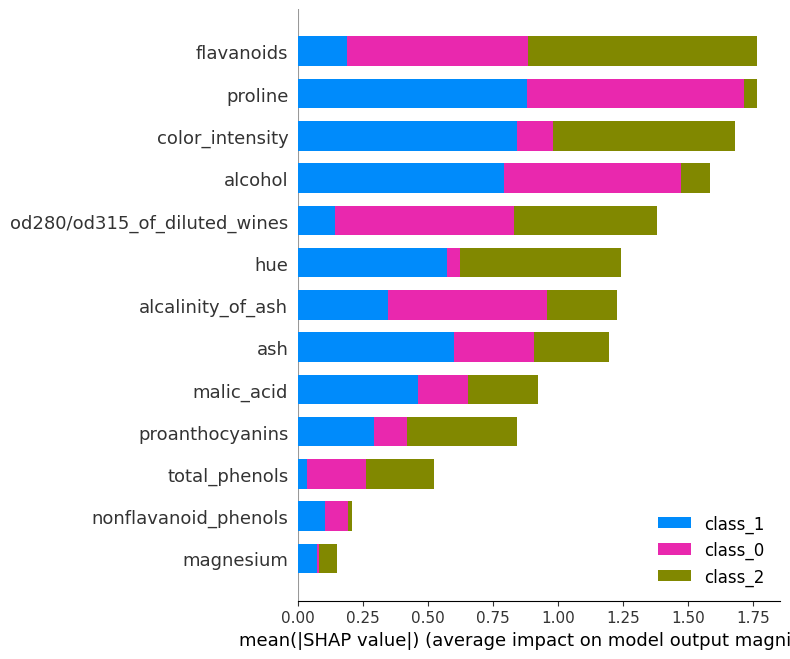

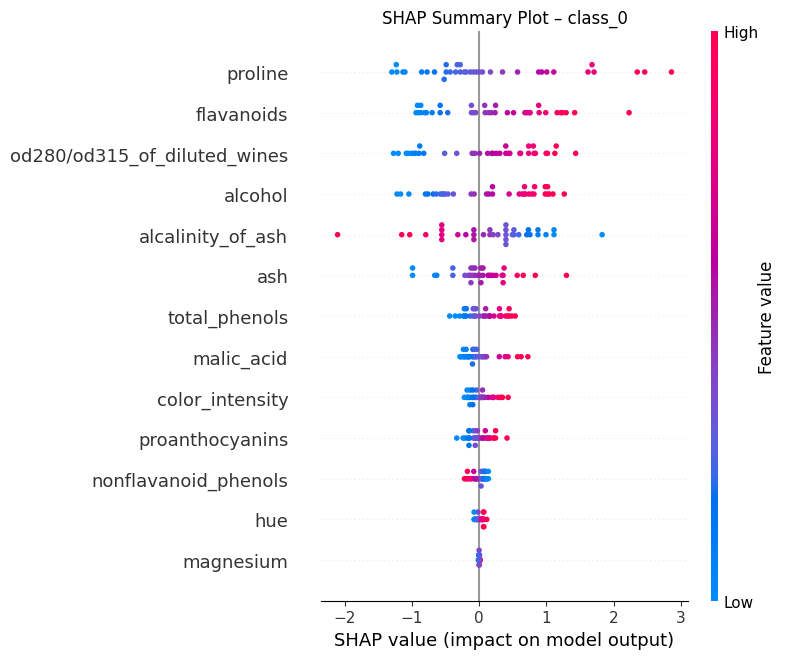

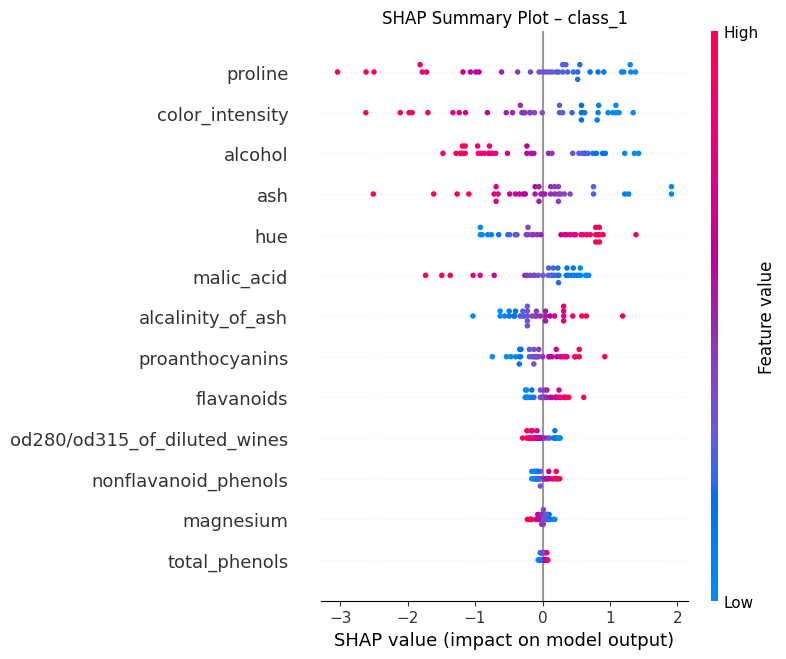

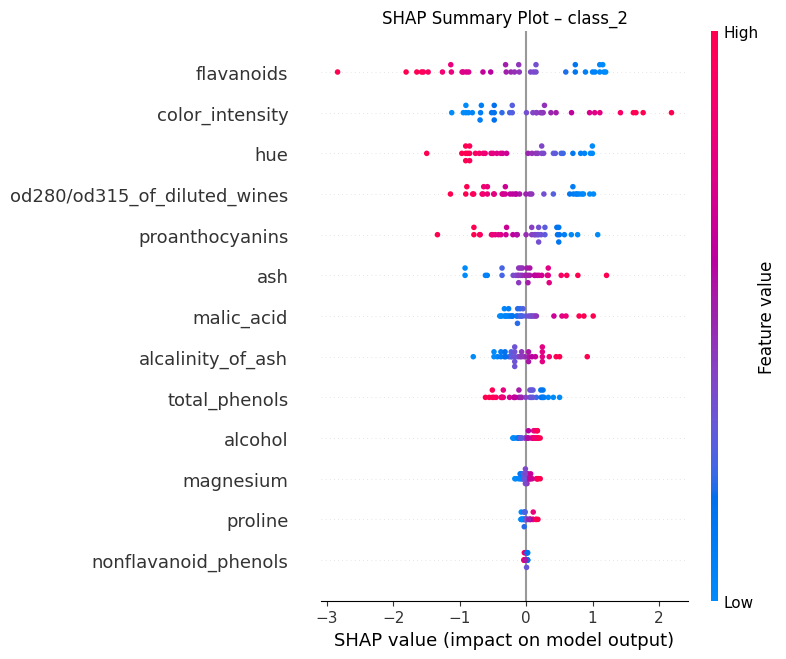

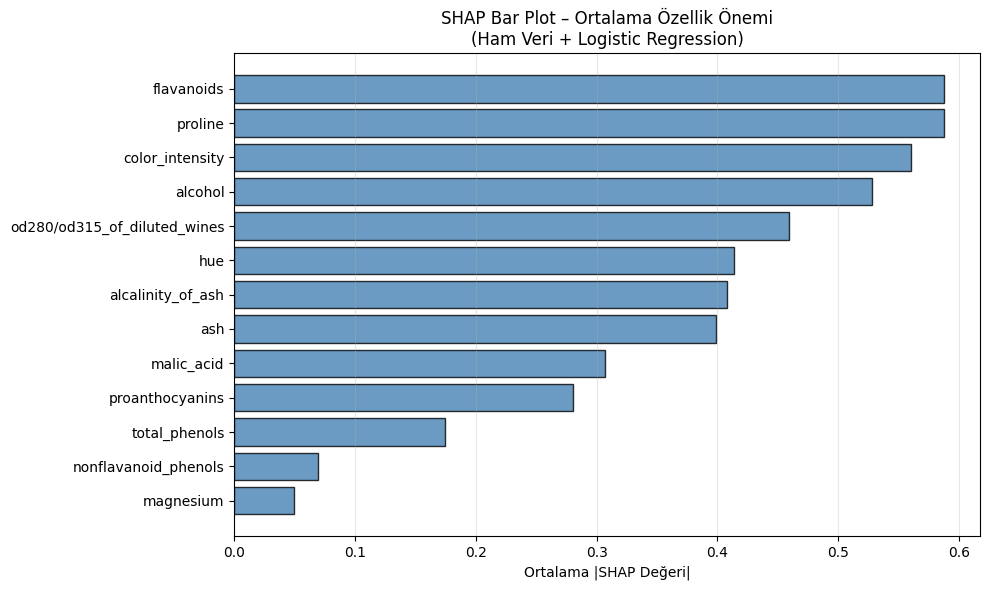


Özellik Önem Sıralaması (SHAP):
Sıra                        Özellik  Ort. |SHAP|
--------------------------------------------------
   1.                   flavanoids : 0.5879
   2.                      proline : 0.5878
   3.              color_intensity : 0.5601
   4.                      alcohol : 0.5283
   5. od280/od315_of_diluted_wines : 0.4593
   6.                          hue : 0.4138
   7.            alcalinity_of_ash : 0.4082
   8.                          ash : 0.3986
   9.                   malic_acid : 0.3072
  10.              proanthocyanins : 0.2805
  11.                total_phenols : 0.1745
  12.         nonflavanoid_phenols : 0.0690
  13.                    magnesium : 0.0498


In [17]:
# BÖLÜM 10.1 – SHAP Analizi

import shap
import numpy as np
import matplotlib.pyplot as plt

# SHAP Explainer
explainer = shap.LinearExplainer(
    best_model,
    X_train_scaled,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test_scaled)

# Yapıyı doğrula
print("shap_values shape:", shap_values.shape)
# (36, 13, 3)

# Sınıf bazlı erişim için son ekseni ayır
# shap_values[:, :, 0] → class_0 için tüm örnekler ve özellikler
# shap_values[:, :, 1] → class_1
# shap_values[:, :, 2] → class_2
shap_values_list = [shap_values[:, :, i]
                    for i in range(3)]  # → 3 ayrı (36, 13) matris

print("Her sınıf için shape:", shap_values_list[0].shape)

# Summary Plot (tüm sınıflar)
plt.figure()
shap.summary_plot(
    shap_values_list,           # Liste formatında veriyoruz
    X_test_scaled,
    feature_names=wine.feature_names,
    class_names=list(wine.target_names),
    plot_type="bar",
    show=True
)

# Her sınıf için ayrı summary plot
for i, cls in enumerate(wine.target_names):
    plt.figure()
    shap.summary_plot(
        shap_values_list[i],    # (36, 13) boyutlu matris
        X_test_scaled,
        feature_names=wine.feature_names,
        show=False
    )
    plt.title(f"SHAP Summary Plot – {cls}")
    plt.tight_layout()
    plt.show()

# Bar Plot (ortalama önem)
mean_shap = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values_list],
    axis=0
)

sorted_idx  = np.argsort(mean_shap)[::-1]
sorted_vals = mean_shap[sorted_idx]
sorted_feat = [wine.feature_names[i] for i in sorted_idx]

plt.figure(figsize=(10, 6))
plt.barh(
    range(len(sorted_feat)),
    sorted_vals[::-1],
    color='steelblue',
    alpha=0.8,
    edgecolor='black'
)
plt.yticks(range(len(sorted_feat)), sorted_feat[::-1])
plt.xlabel('Ortalama |SHAP Değeri|')
plt.title('SHAP Bar Plot – Ortalama Özellik Önemi\n'
          '(Ham Veri + Logistic Regression)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Sayısal sıralama
print("\nÖzellik Önem Sıralaması (SHAP):")
print(f"{'Sıra':>4} {'Özellik':>30} {'Ort. |SHAP|':>12}")
print("-" * 50)
for rank, (feat, val) in enumerate(zip(sorted_feat, sorted_vals), 1):
    print(f"  {rank:>2}. {feat:>28} : {val:.4f}")

# 10.1 SONUC

Bu bölümde, ham veri kullanılarak kurulan Logistic Regression modelinin nasıl karar verdiği, SHAP yöntemi ve özellikle LinearExplainer kullanılarak incelenmiştir. SHAP analizi sayesinde, her bir özelliğin modelin tahminlerine hangi yönde (pozitif/negatif) ve ne kadar katkı sağladığı detaylı bir şekilde görülebilmektedir.

## Genel Özellik Önemi (Bar Plot):
SHAP bar plot grafiği incelendiğinde, model üzerinde en yüksek ortalama etkiye sahip özelliklerin flavanoids (0.59) ve proline (0.59) olduğu görülmektedir. Bu özellikleri sırasıyla color_intensity (0.56), alcohol (0.53) ve od280/od315_of_diluted_wines (0.46) takip etmektedir.

En düşük etkiye sahip özellikler ise nonflavanoid_phenols ve magnesium olarak belirlenmiştir. Elde edilen bu sıralama, önceki bölümde (EDA aşamasında) yapılan boxplot analizleriyle büyük ölçüde uyumludur. Özellikle alcohol, flavanoids ve proline değişkenlerinin sınıflar arasında belirgin bir ayrım oluşturduğu daha önce de gözlemlenmiştir.

## Sınıf Bazlı SHAP Analizi (Dot Plot):

* class_0 için oluşturulan dot plot incelendiğinde, proline ve flavanoids özelliklerinin bu sınıfı belirlemede en önemli değişkenler olduğu anlaşılmaktadır. Özellikle proline değeri yüksek olan örneklerin (grafikte kırmızı ile gösterilen noktalar) pozitif SHAP değerlerine sahip olduğu, yani modelin bu örnekleri class_0 olarak sınıflandırmaya daha yatkın olduğu görülmektedir. Bu durum, EDA aşamasında elde edilen ve class_0 sınıfının yüksek proline değerleriyle karakterize edildiğini gösteren bulgularla örtüşmektedir.

* class_1 için dot plot incelendiğinde ise farklı bir durum ortaya çıkmaktadır. proline ve color_intensity değerleri yüksek olan örneklerin negatif SHAP değerleri aldığı görülmektedir. Bu da modelin bu tür örnekleri class_1 sınıfından uzaklaştırdığını göstermektedir. Yani yüksek proline ve yüksek renk yoğunluğu, class_1 için negatif bir gösterge olarak değerlendirilebilir. Bu bulgu da yine EDA analizinde gözlemlenen, class_1 sınıfının daha düşük proline değerlerine sahip olduğu bilgisiyle uyumludur.

* class_2 için yapılan incelemede ise flavanoids özelliğinin öne çıktığı görülmektedir. Yüksek flavanoids değerine sahip örnekler bu sınıftan uzaklaşırken, düşük değerler class_2 sınıfına yakınlaşmaktadır. Ayrıca color_intensity değişkeni, class_2 için pozitif katkı sağlayan nadir özelliklerden biri olarak dikkat çekmektedir. Yani yüksek renk yoğunluğu bu sınıfa ait olma ihtimalini artırmaktadır.

## Model Performansı ve SHAP İlişkisi:
SHAP analizi sonucunda elde edilen özellik önem sıralaması, modelin neden yüksek performans gösterdiğini de açıklamaktadır. Özellikle flavanoids, proline, color_intensity ve alcohol gibi özellikler, sınıflar arasında belirgin farklılıklar içerdiği için modele güçlü ayırt edici bilgiler sağlamaktadır. Buna karşılık magnesium ve nonflavanoid_phenols gibi özelliklerin SHAP değerlerinin düşük olması, bu değişkenlerin modele katkısının sınırlı olduğunu göstermektedir. Bu durum, daha az sayıda özellik kullanılarak da benzer bir model performansının elde edilebileceğini düşündürmektedir.

# 10.2 PCA ve LDA Temsilleri için SHAP Karşılaştırması

* PCA ile indirgenmiş veride SHAP analizi
* LDA ile indirgenmiş veride SHAP analizi

Sınıfların hangi bileşenlerden etkilendiği tartışın.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


PCA shap shape: (36, 3, 3)


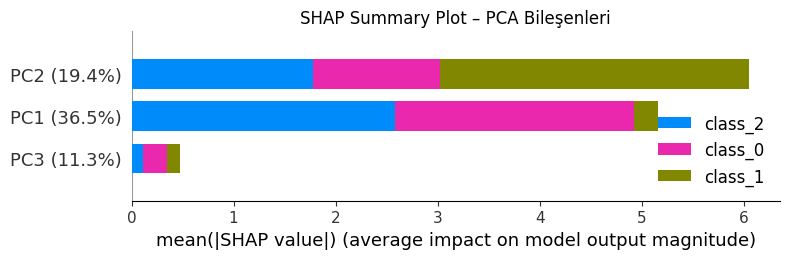


PCA Bileşen Önem Sıralaması (SHAP):
  1. PC1 (36.5%): 1.7205
  2. PC2 (19.4%): 2.0177
  3. PC3 (11.3%): 0.1575

LDA shap shape: (36, 2, 3)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


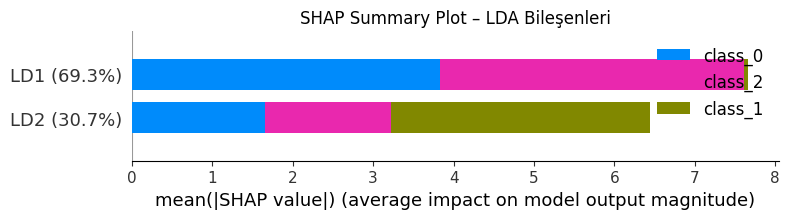


LDA Bileşen Önem Sıralaması (SHAP):
  1. LD1 (69.3%): 2.5541
  2. LD2 (30.7%): 2.1463


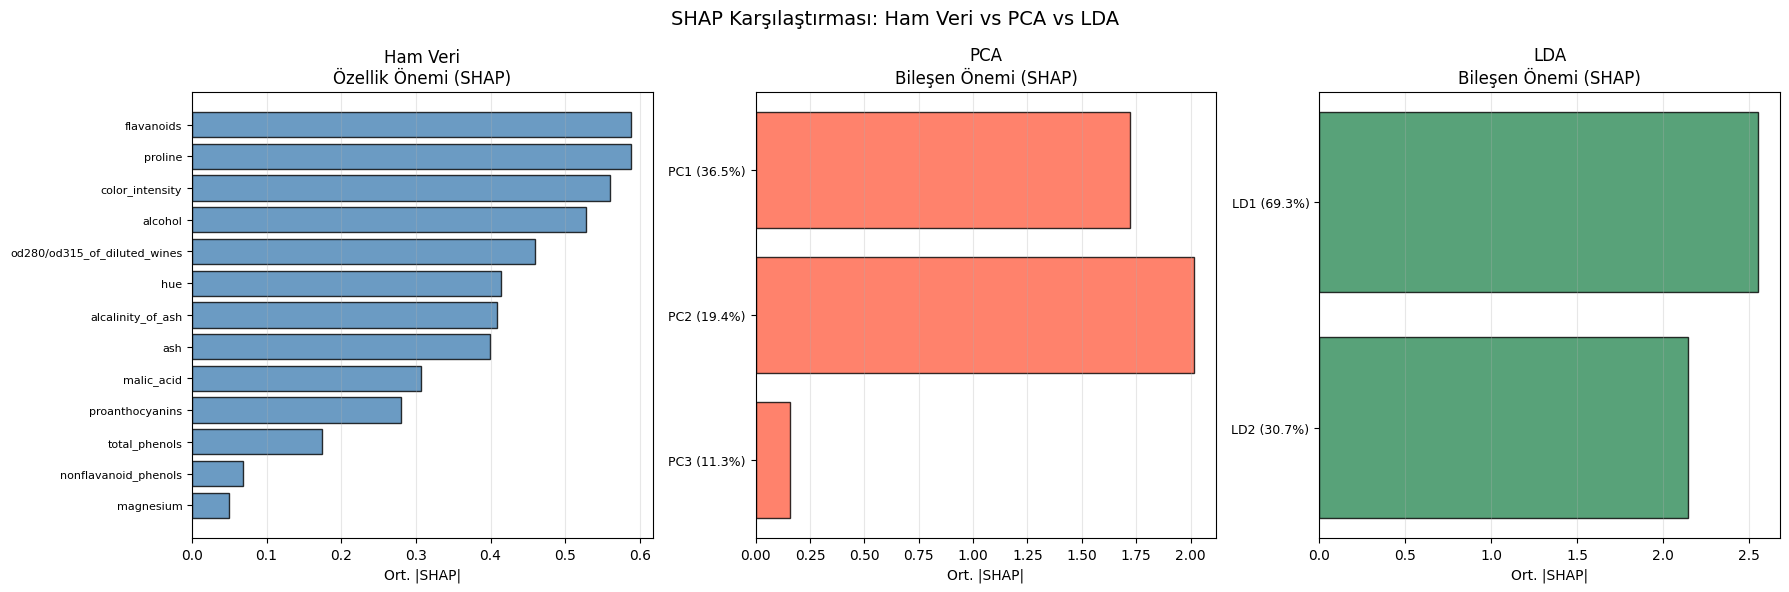

In [19]:
# BÖLÜM 10.2 – PCA ve LDA SHAP Analizi

import shap
import numpy as np
import matplotlib.pyplot as plt

# PCA Modeli için SHAP
best_model_pca = trained_models['PCA_Logistic Regression']['model']

explainer_pca   = shap.LinearExplainer(
    best_model_pca,
    X_train_pca,
    feature_perturbation="interventional"
)
shap_values_pca = explainer_pca.shap_values(X_test_pca)
print("PCA shap shape:", shap_values_pca.shape)

if shap_values_pca.ndim == 3:
    shap_values_pca_list = [shap_values_pca[:, :, i] for i in range(3)]
else:
    shap_values_pca_list = shap_values_pca

# PCA bileşen isimleri
pca_feature_names = [
    f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)'
    for i in range(X_train_pca.shape[1])
]

# PCA Summary Bar Plot
shap.summary_plot(
    shap_values_pca_list,
    X_test_pca,
    feature_names=pca_feature_names,
    class_names=list(wine.target_names),
    plot_type="bar",
    show=False
)
plt.title("SHAP Summary Plot – PCA Bileşenleri")
plt.tight_layout()
plt.show()

# PCA her bileşenin ortalama SHAP değeri
mean_shap_pca = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values_pca_list],
    axis=0
)
print("\nPCA Bileşen Önem Sıralaması (SHAP):")
for i, (feat, val) in enumerate(zip(pca_feature_names, mean_shap_pca)):
    print(f"  {i+1}. {feat}: {val:.4f}")

# LDA Modeli için SHAP
best_model_lda = trained_models['LDA_Logistic Regression']['model']

explainer_lda   = shap.LinearExplainer(
    best_model_lda,
    X_train_lda,
    feature_perturbation="interventional"
)
shap_values_lda = explainer_lda.shap_values(X_test_lda)
print("\nLDA shap shape:", shap_values_lda.shape)

if shap_values_lda.ndim == 3:
    shap_values_lda_list = [shap_values_lda[:, :, i] for i in range(3)]
else:
    shap_values_lda_list = shap_values_lda

# LDA bileşen isimleri
lda_feature_names = [
    f'LD{i+1} ({lda.explained_variance_ratio_[i]*100:.1f}%)'
    for i in range(X_train_lda.shape[1])
]

# LDA Summary Bar Plot
shap.summary_plot(
    shap_values_lda_list,
    X_test_lda,
    feature_names=lda_feature_names,
    class_names=list(wine.target_names),
    plot_type="bar",
    show=False
)
plt.title("SHAP Summary Plot – LDA Bileşenleri")
plt.tight_layout()
plt.show()

# LDA her bileşenin ortalama SHAP değeri
mean_shap_lda = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values_lda_list],
    axis=0
)
print("\nLDA Bileşen Önem Sıralaması (SHAP):")
for i, (feat, val) in enumerate(zip(lda_feature_names, mean_shap_lda)):
    print(f"  {i+1}. {feat}: {val:.4f}")

# Üç Temsili Yan Yana Karşılaştır
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Ham Veri
axes[0].barh(range(len(sorted_feat)),
             sorted_vals[::-1],
             color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_yticks(range(len(sorted_feat)))
axes[0].set_yticklabels(sorted_feat[::-1], fontsize=8)
axes[0].set_title('Ham Veri\nÖzellik Önemi (SHAP)')
axes[0].set_xlabel('Ort. |SHAP|')
axes[0].grid(True, alpha=0.3, axis='x')

# PCA
axes[1].barh(range(len(pca_feature_names)),
             mean_shap_pca[::-1],
             color='tomato', alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(pca_feature_names)))
axes[1].set_yticklabels(pca_feature_names[::-1], fontsize=9)
axes[1].set_title('PCA\nBileşen Önemi (SHAP)')
axes[1].set_xlabel('Ort. |SHAP|')
axes[1].grid(True, alpha=0.3, axis='x')

# LDA
axes[2].barh(range(len(lda_feature_names)),
             mean_shap_lda[::-1],
             color='seagreen', alpha=0.8, edgecolor='black')
axes[2].set_yticks(range(len(lda_feature_names)))
axes[2].set_yticklabels(lda_feature_names[::-1], fontsize=9)
axes[2].set_title('LDA\nBileşen Önemi (SHAP)')
axes[2].set_xlabel('Ort. |SHAP|')
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('SHAP Karşılaştırması: Ham Veri vs PCA vs LDA',
             fontsize=14)
plt.tight_layout()
plt.show()

# 10.2 SONUC

**PCA Bileşenleri için SHAP Analizi:**

PCA temsilinde üç bileşen üzerinden SHAP analizi yapılmıştır. Sonuçlara göre en yüksek ortalama SHAP değerine sahip bileşen PC2'dir (19.4%, SHAP: 2.02). İlginç bir şekilde varyansın %36.5'ini açıklayan PC1 daha düşük bir SHAP değerine (1.72) sahipken, daha az varyans açıklayan PC2'nin model kararlarına daha fazla katkı sağladığı görülüyor. Bu durum PCA'nın sınıf bilgisini kullanmadan çalışmasından kaynaklanabilir; en fazla varyansı açıklayan bileşen her zaman sınıflandırma için en bilgilendirici bileşen olmayabilir. PC3 ise yalnızca 0.16 SHAP değeriyle model kararlarına çok sınırlı katkı sağlamıştır. Renkli bar plot incelendiğinde PC2'nin özellikle class_2 için, PC1'in ise class_0 ve class_1 için belirleyici olduğu görülmektedir.

**LDA Bileşenleri için SHAP Analizi:**

LDA temsilinde iki bileşen üzerinden SHAP analizi yapılmıştır. LD1 (69.3%, SHAP: 2.55) en yüksek SHAP değerine sahiptir. LD2 (30.7%, SHAP: 2.15) ise LD1'e oldukça yakın bir değer almaktadır. Bu sonuç PCA'dan önemli bir farkı göstermektedir; LDA'da açıklanan varyans oranı ile SHAP önem sıralaması birbiriyle tutarlı gözüküyor. Bunun nedeni LDA'nın bileşenlerini sınıf ayrımını maksimize edecek şekilde oluşturmasıdır; dolayısıyla daha fazla sınıflar arası varyans açıklayan bileşen model için de daha önemlidir. Bar plot incelendiğinde LD1'in her üç sınıf için de güçlü katkı sağladığı, LD2'nin ise özellikle class_1 için belirleyici rol oynadığı görülmektedir.

**Üç Temsil Karşılaştırması:**

Yan yana karşılaştırma grafiği incelendiğinde üç temsil arasında önemli farklılıkların olduğu görülmekte. Ham veride özellik önem değerleri 0.05 ile 0.59 arasında geniş bir yelpazede dağılırken PCA'da bileşen başına SHAP değerleri 0.16 ile 2 arasında, LDA'da ise 2.15 ile 2.55 arasında seyretmektedir. LDA bileşenlerinin SHAP değerlerinin hem yüksek hem de birbirine yakın olması, LDA’nın sınıflandırmaya odaklı yapısı sayesinde tüm bileşenlerin modele benzer düzeyde katkı sağladığını göstermektedir. PCA'da ise PC3'ün neredeyse sıfır SHAP değeri alması, bu bileşenin modele anlamsız kaldığını ve boyut indirgeme açısından gereksiz olduğunu gösterir. Ham veride ise 13 özellik arasında magnesium ve nonflavanoid_phenols gibi düşük SHAP değerli özelliklerin bulunması, özellik seçimi yapılarak modelin sadeleştirilebileceğine göstermektedir.